# NOTEBOOK MODELO

In [1]:
# import tensorflow.compat.v1 as tf
# tf.disable_eager_execution()

In [2]:
# !pip install aif360

In [3]:
# !pip install tensorflow==1.15

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import f_oneway

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# from aif360.datasets import BinaryLabelDataset
# from aif360.algorithms.inprocessing import AdversarialDebiasing
# import tensorflow as tf

# from fairlearn.reductions import ExponentiatedGradient, DemographicParity

from itertools import product

import warnings
warnings.filterwarnings('ignore')

In [5]:
df_model = pd.read_csv(r'..\00_Data\00_Processed\df_model.csv')

In [6]:
df_model.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age', 'age_cat',
       'total_priors_count', 'adult_priors_count', 'juv_priors_count',
       'c_charge_degree', 'maritalstatus', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'is_violent', 'is_drug', 'is_property', 'is_fraud',
       'is_weapon', 'is_traffic', 'is_sexual', 'is_public_disorder',
       'is_justice_related', 'no_charge', 'maritalstatus_other',
       'maritalstatus_separated', 'maritalstatus_significant other',
       'log_juv_priors_count', 'log_adult_priors_count', 'adult_priors_freq',
       'adult_priors_freq_2', 'adult_priors_freq_3'],
      dtype='object')

## Nuestro Modelo v.1.0

In [7]:
# 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other',

In [8]:
drop_col_list = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq', 'adult_priors_freq_2',
       'adult_priors_freq_3',  'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex', "juv_priors_count", "adult_priors_count", "log_juv_priors_count", "log_adult_priors_count", 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'age_cat']       #revisar una vez esté todo claro

In [9]:
outliers_col_list = [
    'age',
    'total_priors_count',
    'juv_priors_count',
]

for col in outliers_col_list:

    upper = df_model[col].quantile(0.99)

    no_outlier_df = df_model[
        df_model[col] <= upper
    ]


Classification report:
              precision    recall  f1-score   support

           0       0.79      0.65      0.71       779
           1       0.52      0.69      0.60       435

    accuracy                           0.66      1214
   macro avg       0.66      0.67      0.65      1214
weighted avg       0.69      0.66      0.67      1214

ROC AUC: 0.7273825859855695
              Variable  Coefficient
0                  age    -0.046111
1   total_priors_count     0.158504
2      c_charge_degree    -0.165388
3           is_violent    -0.308887
4              is_drug    -0.078246
5          is_property    -0.166139
6             is_fraud    -0.285812
7            is_weapon    -0.081356
8           is_traffic    -0.332056
9            is_sexual     0.000000
10  is_public_disorder     0.000000
11  is_justice_related     0.000000
12           no_charge    -0.172418
Confusion matrix:




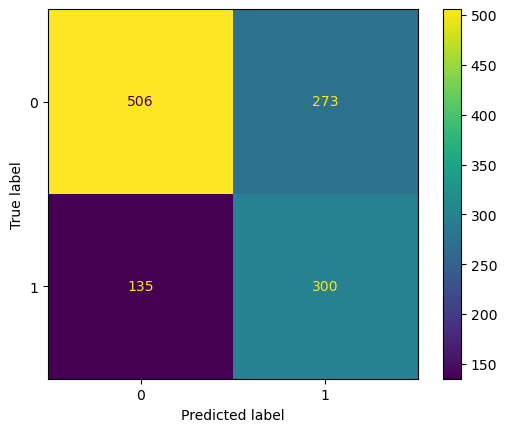

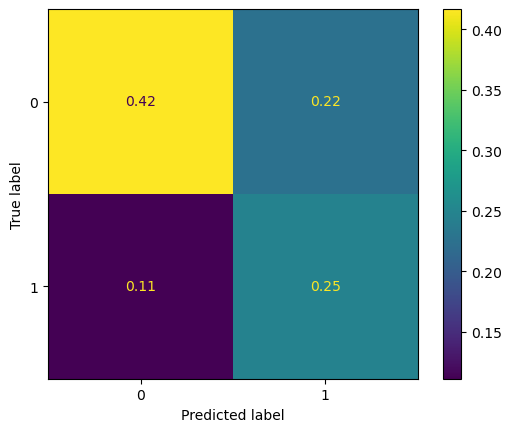

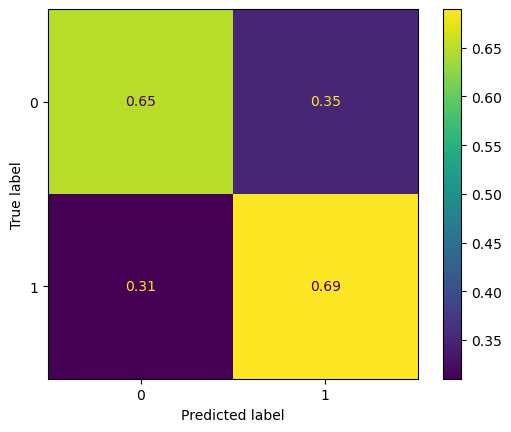




=== Race: other ===


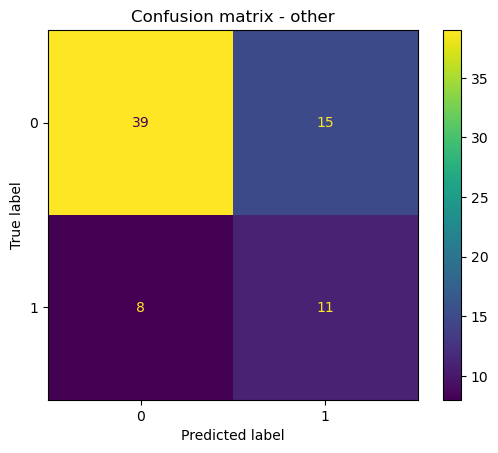

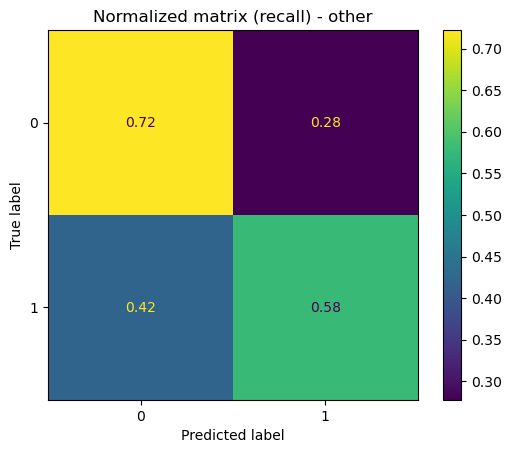


=== Race: african-american ===


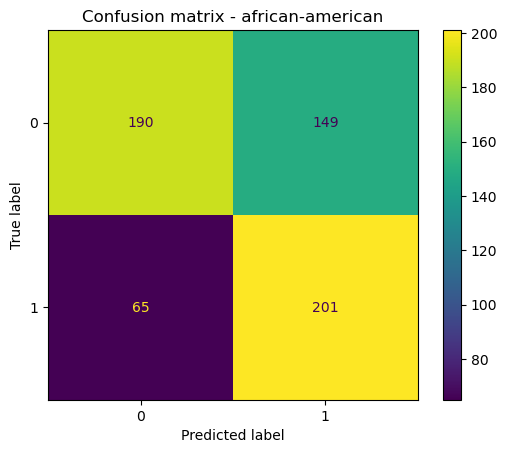

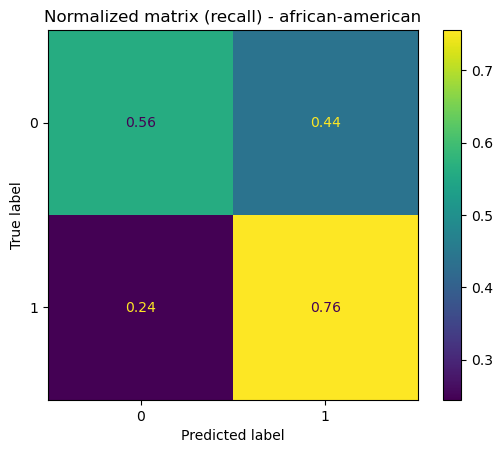


=== Race: hispanic ===


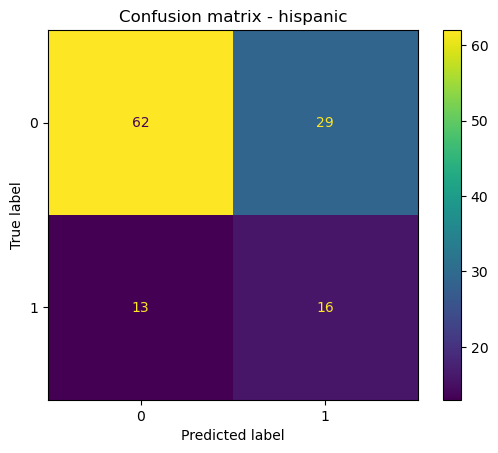

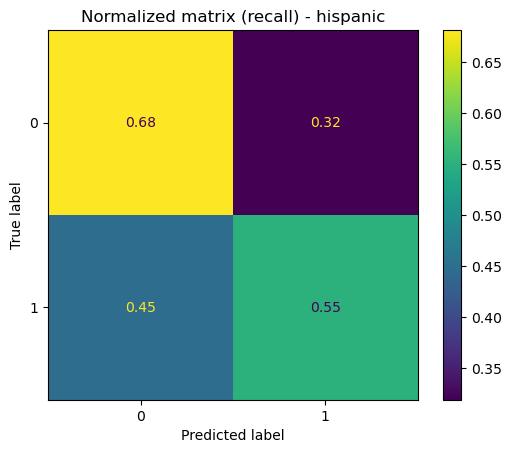


=== Race: caucasian ===


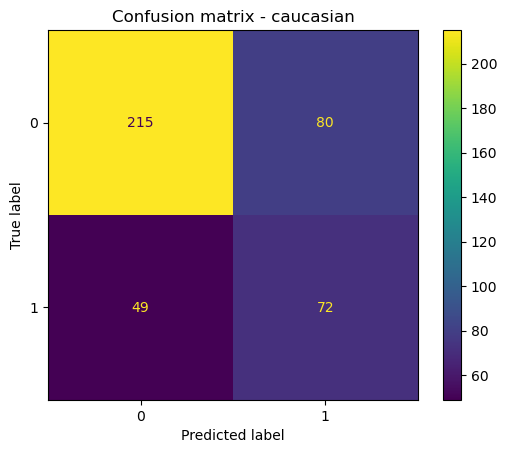

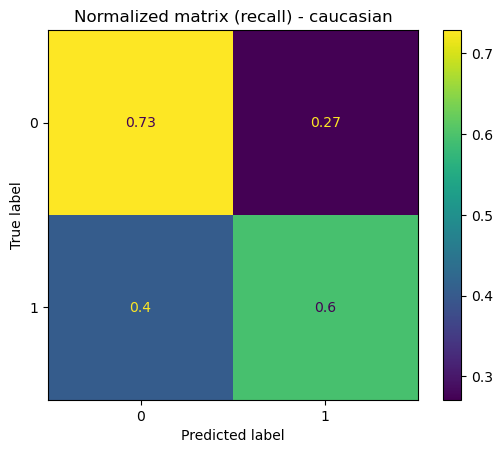

In [10]:
X = no_outlier_df.drop(columns=drop_col_list)
y = no_outlier_df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 69, stratify = y)

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight='balanced')

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.505).astype(int)


print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print(coefficients)

print("Confusion matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")

race_test = no_outlier_df.loc[X_test.index, 'race']

races = race_test.unique()

for race in races:
    idx = race_test == race
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Race: {race} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix (recall) - {race}")
    plt.show()

In [11]:
# model = BaggingClassifier(
#     estimator=LogisticRegression(penalty='l1', solver='liblinear', class_weight = 'balanced'),
#     n_estimators=10
# )

# model.fit(X_train, y_train)

# y_proba = model.predict_proba(X_test)[:,1]
# y_pred = (y_proba >= 0.515).astype(int)

# print("Classification report:")
# print(classification_report(y_test, y_pred))
# print("ROC AUC:", roc_auc_score(y_test, y_proba))


# print("Confusion matrix:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
# disp.plot()
# print("\n")
# disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
# disp.plot()
# disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
# disp.plot()
# plt.show()
# print("\n")

## Modelo v.1.1

In [12]:
df_model.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age', 'age_cat',
       'total_priors_count', 'adult_priors_count', 'juv_priors_count',
       'c_charge_degree', 'maritalstatus', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'is_violent', 'is_drug', 'is_property', 'is_fraud',
       'is_weapon', 'is_traffic', 'is_sexual', 'is_public_disorder',
       'is_justice_related', 'no_charge', 'maritalstatus_other',
       'maritalstatus_separated', 'maritalstatus_significant other',
       'log_juv_priors_count', 'log_adult_priors_count', 'adult_priors_freq',
       'adult_priors_freq_2', 'adult_priors_freq_3'],
      dtype='object')

In [13]:
drop_col_list = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq', 'adult_priors_freq_2',
       'adult_priors_freq_3', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex', 'total_priors_count',
       'log_juv_priors_count', 'log_adult_priors_count', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'age_cat']


Classification report:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73       779
           1       0.54      0.67      0.60       435

    accuracy                           0.68      1214
   macro avg       0.67      0.68      0.67      1214
weighted avg       0.70      0.68      0.69      1214

ROC AUC: 0.7308662741799832
              Variable  Coeficiente
0                  age    -0.042732
1   adult_priors_count     0.151975
2     juv_priors_count     0.371110
3      c_charge_degree    -0.187195
4           is_violent    -0.370191
5              is_drug    -0.166913
6          is_property    -0.241651
7             is_fraud    -0.354841
8            is_weapon    -0.124187
9           is_traffic    -0.380794
10           is_sexual    -0.144833
11  is_public_disorder    -0.039677
12  is_justice_related    -0.052241
13           no_charge    -0.227251
Confusion matrix:




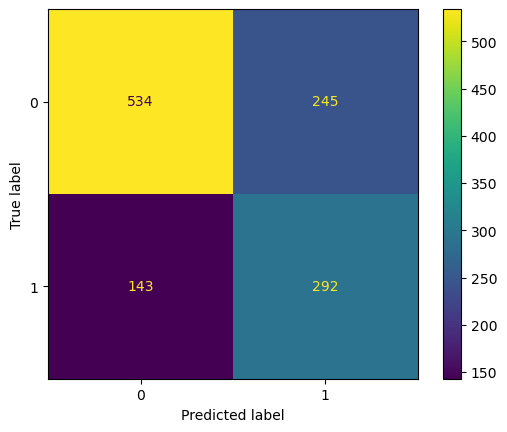

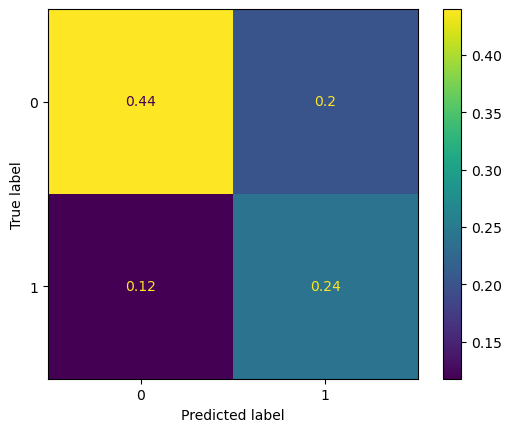

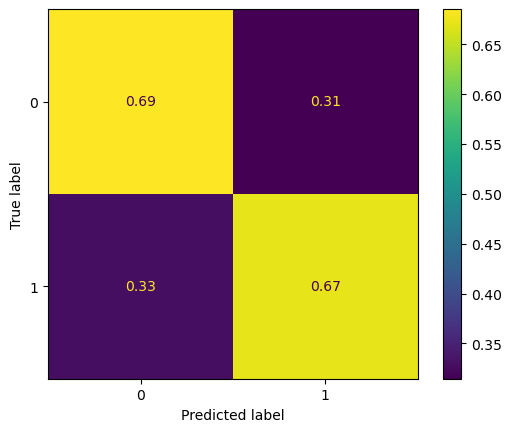



Classification report:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73       779
           1       0.54      0.67      0.60       435

    accuracy                           0.68      1214
   macro avg       0.67      0.68      0.67      1214
weighted avg       0.70      0.68      0.69      1214

ROC AUC: 0.7308662741799832

=== Race: other ===


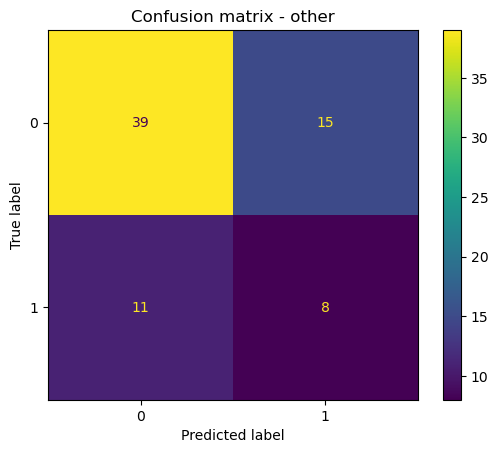

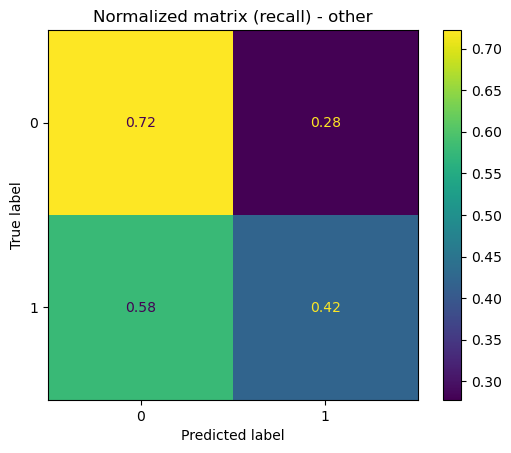


=== Race: african-american ===


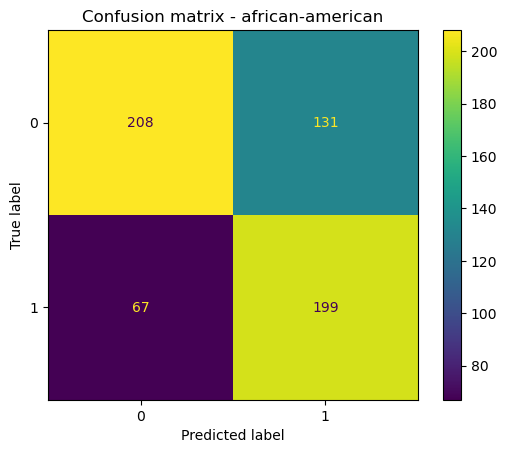

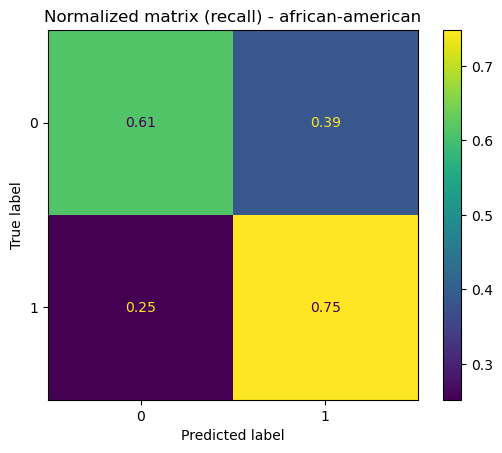


=== Race: hispanic ===


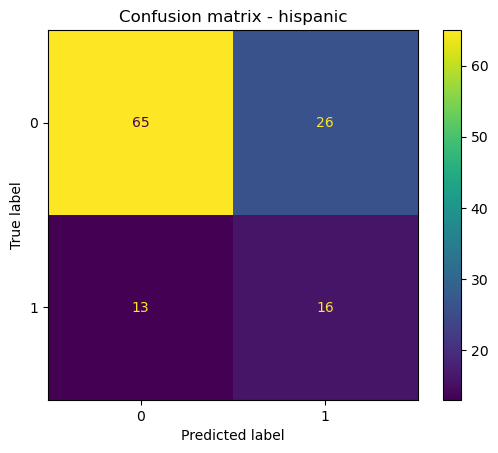

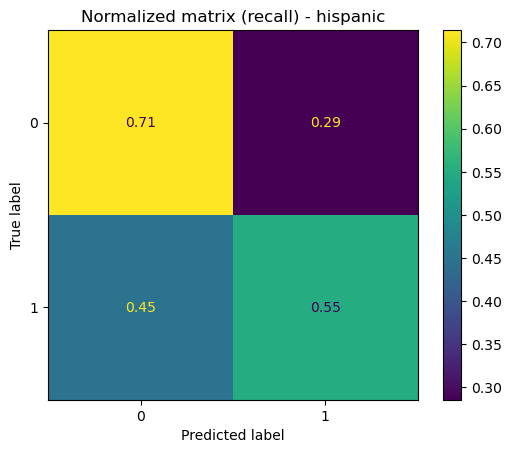


=== Race: caucasian ===


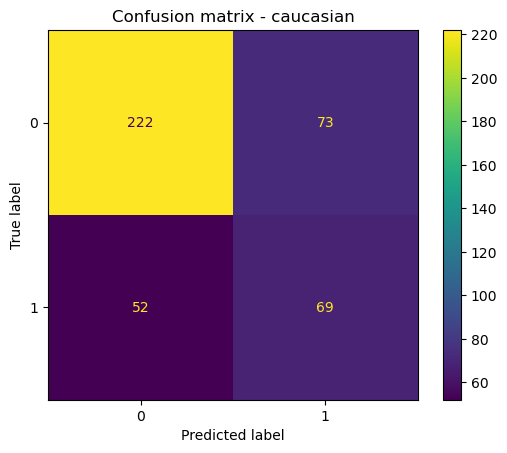

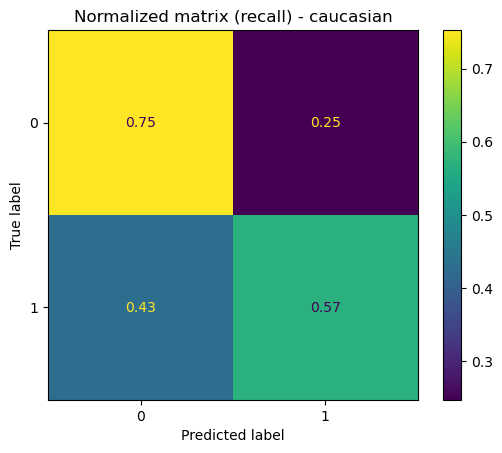

In [ ]:
X1 = no_outlier_df.drop(columns=drop_col_list)
y1 = no_outlier_df['two_year_recid']

X1_train, X1_test, y1_train, y1_test, = train_test_split(X1, y1, test_size = 0.2, random_state = 69, stratify = y1)

model1 = LogisticRegression(max_iter=1000, penalty='l2', solver='liblinear', class_weight='balanced')

model1.fit(X1_train, y1_train)

y1_proba = model1.predict_proba(X1_test)[:,1]
y1_pred = (y1_proba >= 0.515).astype(int)

print("\nClassification report:")
print(classification_report(y1_test, y1_pred))
print("ROC AUC:", roc_auc_score(y1_test, y1_proba))

coefficients = pd.DataFrame({
    'Variable': X1.columns,
    'Coefficient': model1.coef_[0]
})

print(coefficients)

print("Confusion matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Classification report:")
print(classification_report(y1_test, y1_pred))
print("ROC AUC:", roc_auc_score(y1_test, y1_proba))

race_test = no_outlier_df.loc[X1_test.index, 'race']

races = race_test.unique()

for race in races:
    idx = race_test == race
    
    y_true_r = y1_test[idx]
    y_pred_r = y1_pred[idx]
    
    print(f"\n=== Race: {race} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix (recall) - {race}")
    plt.show()

In [15]:
# model1 = BaggingClassifier(
#     estimator=LogisticRegression(penalty='l1', solver='liblinear'),
#     n_estimators=10
# )

# model1.fit(X1_train, y1_train, sample_weight = w1_train)

# y1_proba = model1.predict_proba(X1_test)[:,1]
# y1_pred = (y1_proba >= 0.37).astype(int)


# print("Classification report:")
# print(classification_report(y1_test, y1_pred))
# print("ROC AUC:", roc_auc_score(y1_test, y1_proba))

# print("Confusion matrix:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred))
# disp.plot()
# print("\n")
# disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "all"))
# disp.plot()
# disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "true"))
# disp.plot()
# plt.show()
# print("\n")


# race_test = no_outlier_df.loc[X1_test.index, 'race']

# races = race_test.unique()

# for race in races:
#     idx = race_test == race
    
#     y_true_r = y1_test[idx]
#     y_pred_r = y1_pred[idx]
    
#     print(f"\n=== Race: {race} ===")
    
#     cm = confusion_matrix(y_true_r, y_pred_r)
#     disp = ConfusionMatrixDisplay(cm)
#     disp.plot()
#     plt.title(f"Confusion matrix - {race}")
#     plt.show()
    
#     cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
#     disp = ConfusionMatrixDisplay(cm_norm)
#     disp.plot()
#     plt.title(f"Normalized matrix (recall) - {race}")
#     plt.show()

## Modelo v.1.2

In [16]:
df_model.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age', 'age_cat',
       'total_priors_count', 'adult_priors_count', 'juv_priors_count',
       'c_charge_degree', 'maritalstatus', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'is_violent', 'is_drug', 'is_property', 'is_fraud',
       'is_weapon', 'is_traffic', 'is_sexual', 'is_public_disorder',
       'is_justice_related', 'no_charge', 'maritalstatus_other',
       'maritalstatus_separated', 'maritalstatus_significant other',
       'log_juv_priors_count', 'log_adult_priors_count', 'adult_priors_freq',
       'adult_priors_freq_2', 'adult_priors_freq_3'],
      dtype='object')

In [17]:
drop_col_list = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq',
       'adult_priors_freq_2', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'total_priors_count', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other',
       'adult_priors_count', 'juv_priors_count', 'age_cat']


Classification report:
              precision    recall  f1-score   support

           0       0.80      0.64      0.71       779
           1       0.52      0.71      0.60       435

    accuracy                           0.66      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.66      0.67      1214

ROC AUC: 0.7402446401959482
                  Variable  Coeficiente
0                      sex    -0.359869
1                      age    -0.041587
2          c_charge_degree    -0.152415
3               is_violent    -0.251846
4                  is_drug    -0.088013
5              is_property    -0.101572
6                 is_fraud    -0.252531
7                is_weapon    -0.092628
8               is_traffic    -0.348709
9                is_sexual     0.000000
10      is_public_disorder     0.000000
11      is_justice_related    -0.021373
12               no_charge    -0.250783
13    log_juv_priors_count     0.727223
14  log_adult_priors_

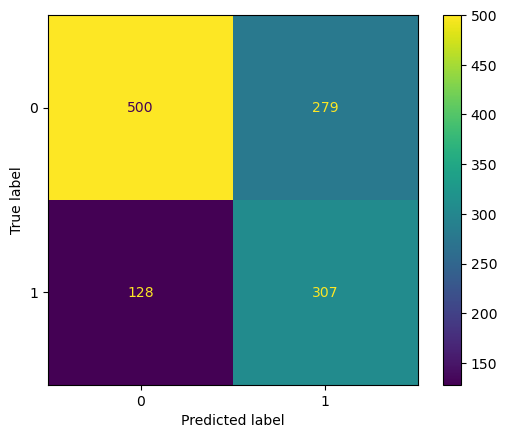

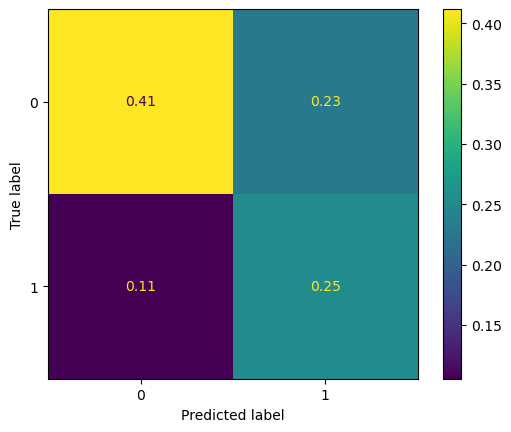

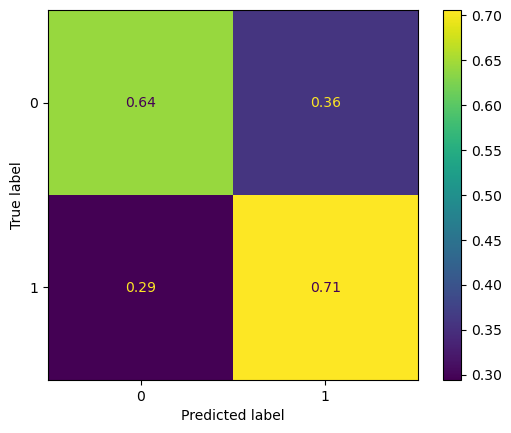




=== Race: other ===


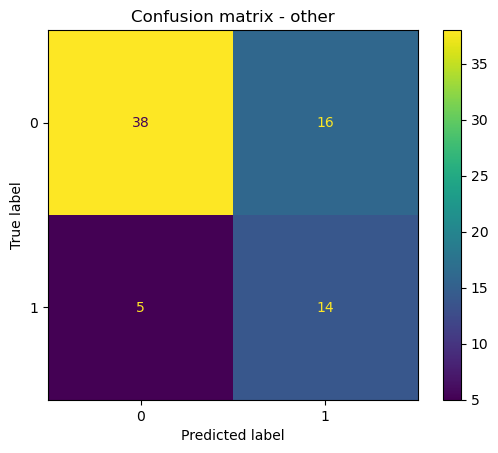

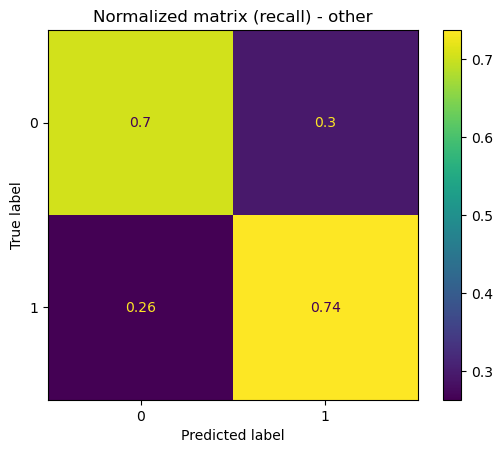


=== Race: african-american ===


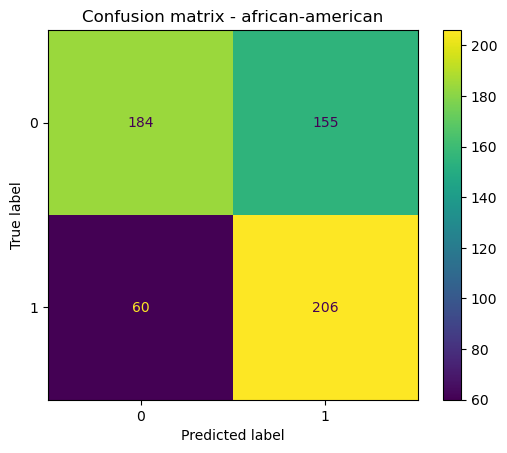

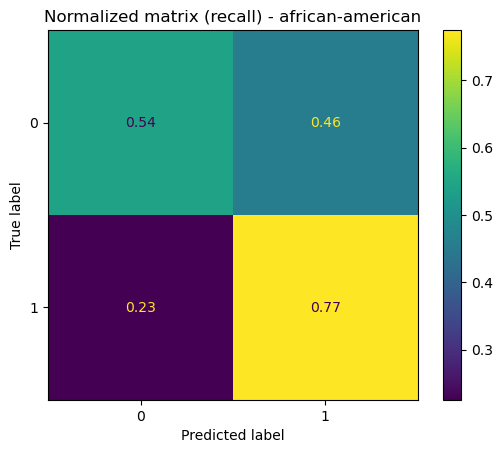


=== Race: hispanic ===


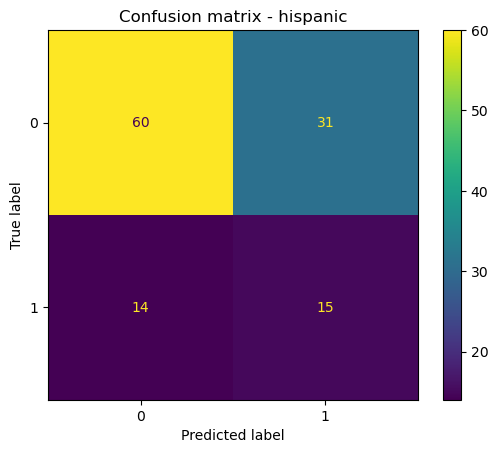

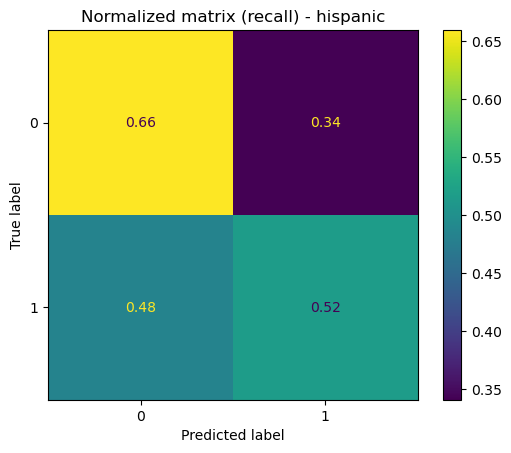


=== Race: caucasian ===


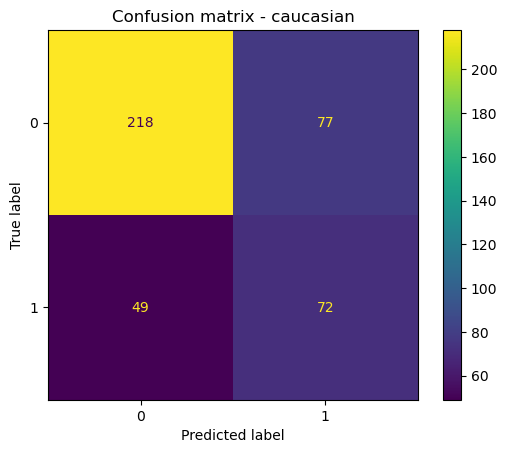

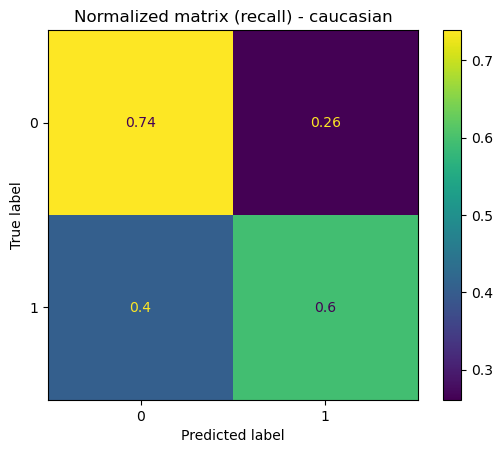

In [ ]:
X2 = no_outlier_df.drop(columns=drop_col_list)
y2 = no_outlier_df['two_year_recid']

X2_train, X2_test, y2_train, y2_test= train_test_split(X2, y2, test_size = 0.2, random_state = 69, stratify = y2)

model2 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight='balanced')

model2.fit(X2_train, y2_train)

y2_proba = model2.predict_proba(X2_test)[:,1]
y2_pred = (y2_proba >= 0.495).astype(int)

print("\nClassification report:")
print(classification_report(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba))

coefficients = pd.DataFrame({
    'Variable': X2.columns,
    'Coefficient': model2.coef_[0]
})

print(coefficients)

print("Confusion matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")

race_test = no_outlier_df.loc[X2_test.index, 'race']

races = race_test.unique()

for race in races:
    idx = race_test == race
    
    y_true_r = y2_test[idx]
    y_pred_r = y2_pred[idx]
    
    print(f"\n=== Race: {race} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix (recall) - {race}")
    plt.show()

In [19]:
# model2 = BaggingClassifier(
#     estimator=LogisticRegression(penalty='l1', solver='liblinear'),
#     n_estimators=10
# )

# model2.fit(X2_train, y2_train, sample_weight=w2_train)

# y2_proba = model2.predict_proba(X2_test)[:,1]
# y2_pred = (y2_proba >= 0.37).astype(int)


# print("Confusion matrix:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred))
# disp.plot()
# print("\n")
# disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "all"))
# disp.plot()
# disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "true"))
# disp.plot()
# plt.show()
# print("\n")
# print("Classification report:")
# print(classification_report(y2_test, y2_pred))
# print("ROC AUC:", roc_auc_score(y2_test, y2_proba))

## Modelo v1.3

In [20]:
df_model.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age', 'age_cat',
       'total_priors_count', 'adult_priors_count', 'juv_priors_count',
       'c_charge_degree', 'maritalstatus', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'is_violent', 'is_drug', 'is_property', 'is_fraud',
       'is_weapon', 'is_traffic', 'is_sexual', 'is_public_disorder',
       'is_justice_related', 'no_charge', 'maritalstatus_other',
       'maritalstatus_separated', 'maritalstatus_significant other',
       'log_juv_priors_count', 'log_adult_priors_count', 'adult_priors_freq',
       'adult_priors_freq_2', 'adult_priors_freq_3'],
      dtype='object')

In [21]:
drop_col_list = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq',
       'adult_priors_freq_3', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex', 'total_priors_count',
       'log_juv_priors_count', 'log_adult_priors_count', "adult_priors_count", 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'age_cat']


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       779
           1       0.54      0.68      0.60       435

    accuracy                           0.68      1214
   macro avg       0.66      0.68      0.66      1214
weighted avg       0.70      0.68      0.68      1214

ROC AUC: 0.7310359582724685
               Variable  Coeficiente
0                   age    -0.029485
1      juv_priors_count     0.365894
2       c_charge_degree    -0.169620
3            is_violent    -0.309589
4               is_drug    -0.081511
5           is_property    -0.162074
6              is_fraud    -0.266811
7             is_weapon    -0.091491
8            is_traffic    -0.344486
9             is_sexual    -0.019077
10   is_public_disorder     0.000000
11   is_justice_related     0.000000
12            no_charge    -0.194247
13  adult_priors_freq_2    10.401917
Confusion matrix:




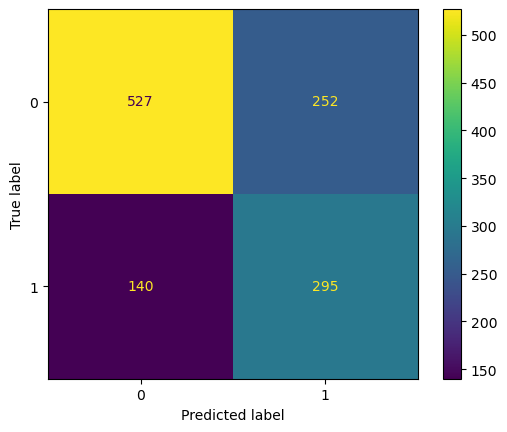

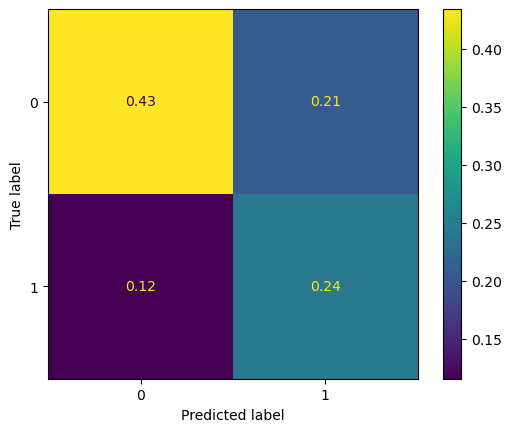

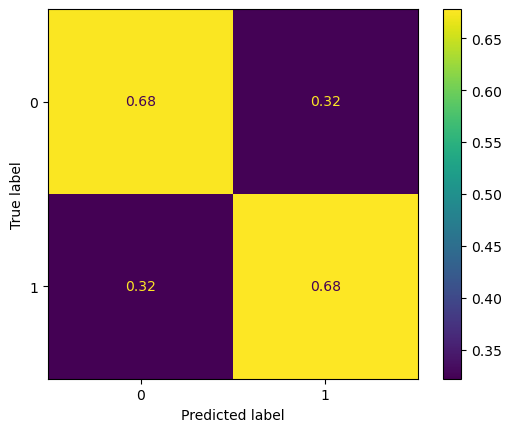



Classification report:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       779
           1       0.54      0.68      0.60       435

    accuracy                           0.68      1214
   macro avg       0.66      0.68      0.66      1214
weighted avg       0.70      0.68      0.68      1214

ROC AUC: 0.7310359582724685


In [ ]:
X3 = no_outlier_df.drop(columns=drop_col_list)
y3 = no_outlier_df['two_year_recid']

X3_train, X3_test, y3_train, y3_test= train_test_split(X3, y3, test_size = 0.2, random_state = 69, stratify = y3)

model3 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight = 'balanced')

model3.fit(X3_train, y3_train)

y3_proba = model3.predict_proba(X3_test)[:,1]
y3_pred = (y3_proba >= 0.505).astype(int)


print("\nRanking report:")
print(classification_report(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_proba))

coefficients = pd.DataFrame({
    'Variable': X3.columns,
    'Coefficient': model3.coef_[0]
})

print(coefficients)

print("Confusion matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Classification report:")
print(classification_report(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_proba))

In [23]:

# model3 = BaggingClassifier(
#     estimator=LogisticRegression(penalty='l1', solver='liblinear'),
#     n_estimators=10
# )

# model3.fit(X3_train, y3_train, sample_weight=w3_train)

# y3_proba = model3.predict_proba(X3_test)[:,1]
# y3_pred = (y3_proba >= 0.37).astype(int)


# print("Confusion matrix:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred))
# disp.plot()
# print("\n")
# disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "all"))
# disp.plot()
# disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "true"))
# disp.plot()
# plt.show()
# print("\n")
# print("Classification report:")
# print(classification_report(y3_test, y3_pred))
# print("ROC AUC:", roc_auc_score(y3_test, y3_proba))

# race_test = no_outlier_df.loc[X3_test.index, 'race']

# races = race_test.unique()

# for race in races:
#     idx = race_test == race
    
#     y_true_r = y3_test[idx]
#     y_pred_r = y3_pred[idx]
    
#     print(f"\n=== Race: {race} ===")
    
#     cm = confusion_matrix(y_true_r, y_pred_r)
#     disp = ConfusionMatrixDisplay(cm)
#     disp.plot()
#     plt.title(f"Confusion matrix - {race}")
#     plt.show()
    
#     # Normalizada (recall)
#     cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
#     disp = ConfusionMatrixDisplay(cm_norm)
#     disp.plot()
#     plt.title(f"Normalized matrix (recall) - {race}")
#     plt.show()

## Modelo v.2.0

In [24]:
df_model.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age', 'age_cat',
       'total_priors_count', 'adult_priors_count', 'juv_priors_count',
       'c_charge_degree', 'maritalstatus', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'is_violent', 'is_drug', 'is_property', 'is_fraud',
       'is_weapon', 'is_traffic', 'is_sexual', 'is_public_disorder',
       'is_justice_related', 'no_charge', 'maritalstatus_other',
       'maritalstatus_separated', 'maritalstatus_significant other',
       'log_juv_priors_count', 'log_adult_priors_count', 'adult_priors_freq',
       'adult_priors_freq_2', 'adult_priors_freq_3'],
      dtype='object')

In [25]:
drop_col_list = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq',
       'adult_priors_freq_3', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex', 'total_priors_count',
       'log_juv_priors_count', 'log_adult_priors_count', 'adult_priors_count', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'age_cat']

### Modelo MAYOR PRECISIÓN - sin RW


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       779
           1       0.54      0.68      0.60       435

    accuracy                           0.68      1214
   macro avg       0.66      0.68      0.66      1214
weighted avg       0.70      0.68      0.68      1214

ROC AUC: 0.7310123500509053
               Variable  Coeficiente
0                   age    -0.029464
1      juv_priors_count     0.366005
2       c_charge_degree    -0.169256
3            is_violent    -0.309051
4               is_drug    -0.080670
5           is_property    -0.161241
6              is_fraud    -0.265957
7             is_weapon    -0.091134
8            is_traffic    -0.344030
9             is_sexual    -0.018507
10   is_public_disorder     0.000000
11   is_justice_related     0.000000
12            no_charge    -0.193850
13  adult_priors_freq_2    10.403514
Confusion matrix:




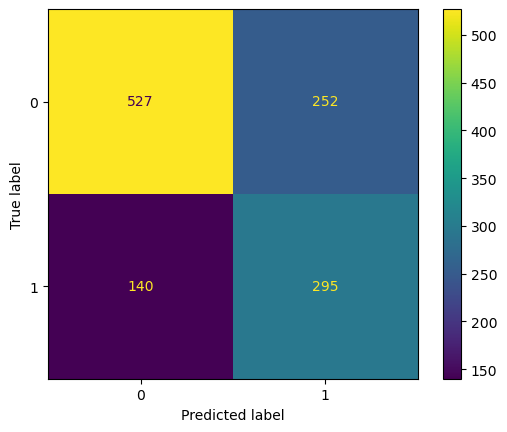

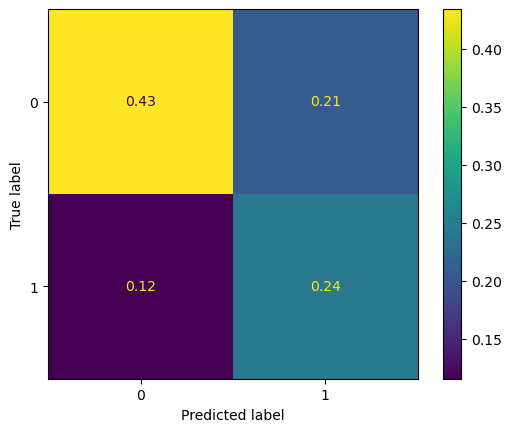

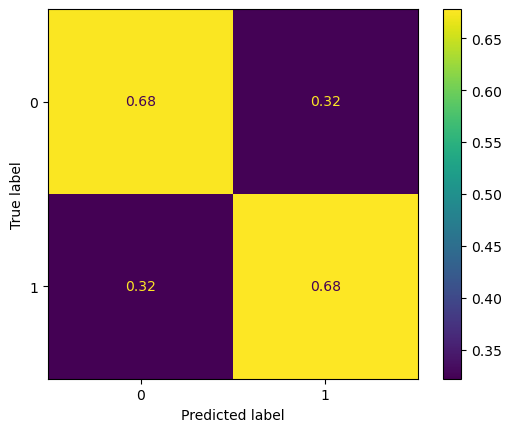




=== Race: other ===


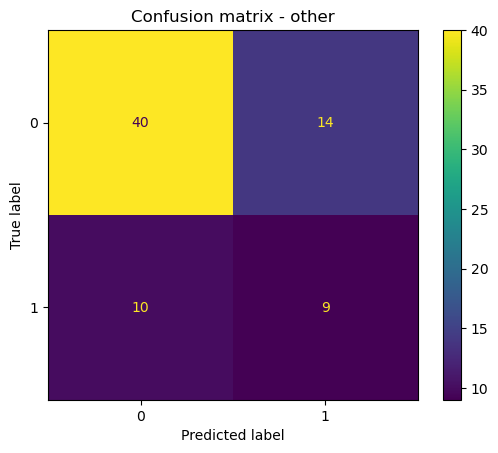

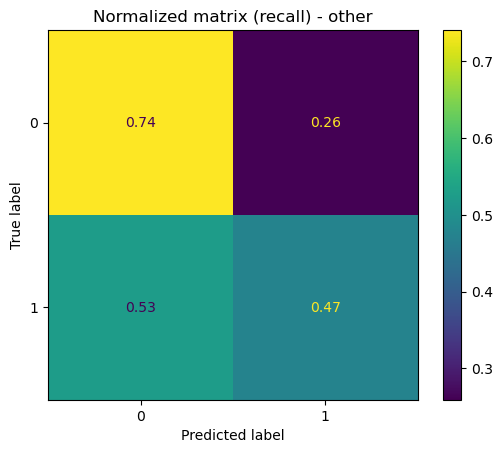


=== Race: african-american ===


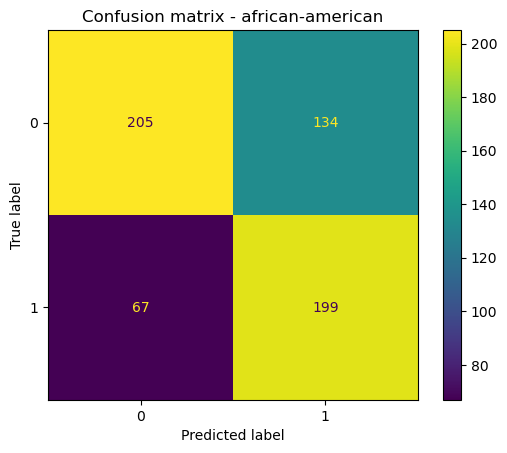

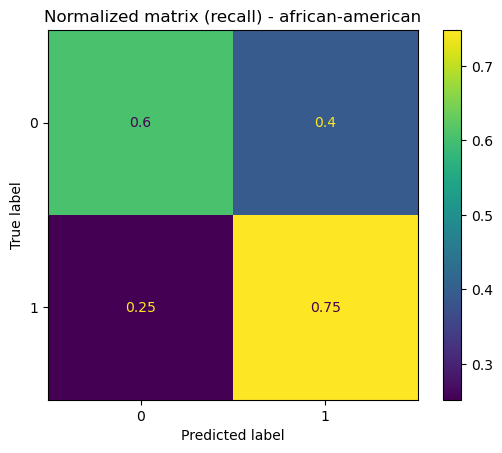


=== Race: hispanic ===


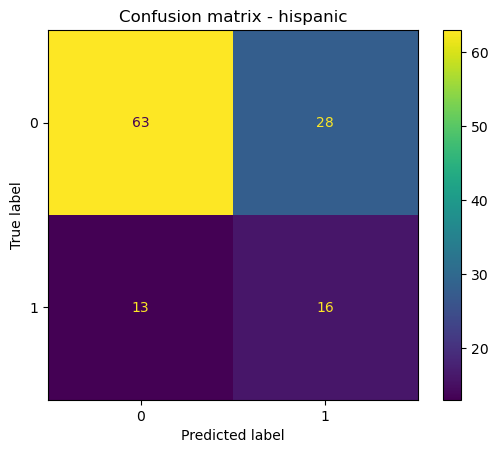

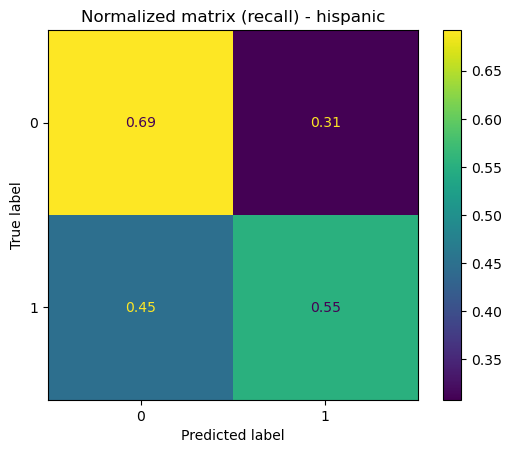


=== Race: caucasian ===


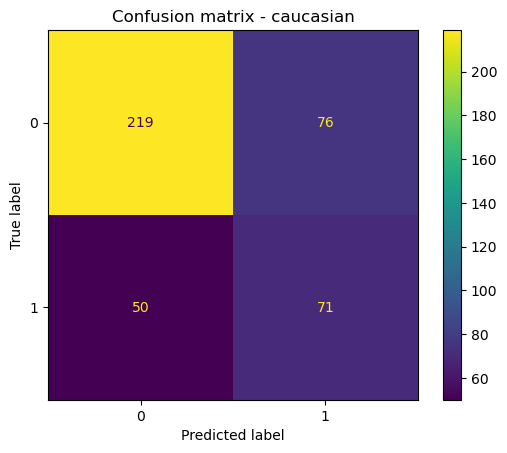

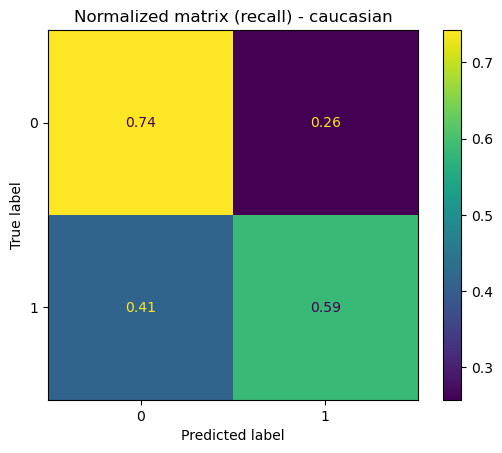

In [ ]:
X = no_outlier_df.drop(columns=drop_col_list)
y = no_outlier_df['two_year_recid']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.2, random_state = 69, stratify = y)

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight = 'balanced')

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.505).astype(int)


print("\nRanking report:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print(coefficients)

print("Confusion matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")


race_test = no_outlier_df.loc[X_test.index, 'race']

races = race_test.unique()

for race in races:
    idx = race_test == race
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Race: {race} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix (recall) - {race}")
    plt.show()

### Modelo MAYOR PRECISIÓN - Con RW

este es el bueno de los q conservan sesgo


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.68      0.73       779
           1       0.54      0.66      0.59       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.68      1214

ROC AUC: 0.7323757248461777
               Variable  Coeficiente
0                   age    -0.028398
1      juv_priors_count     0.361990
2       c_charge_degree    -0.202838
3            is_violent    -0.229514
4               is_drug     0.000000
5           is_property    -0.137134
6              is_fraud    -0.248535
7             is_weapon    -0.156950
8            is_traffic    -0.295007
9             is_sexual    -0.099942
10   is_public_disorder     0.000000
11   is_justice_related    -0.000546
12            no_charge    -0.180929
13  adult_priors_freq_2    11.109158
Confusion matrix:




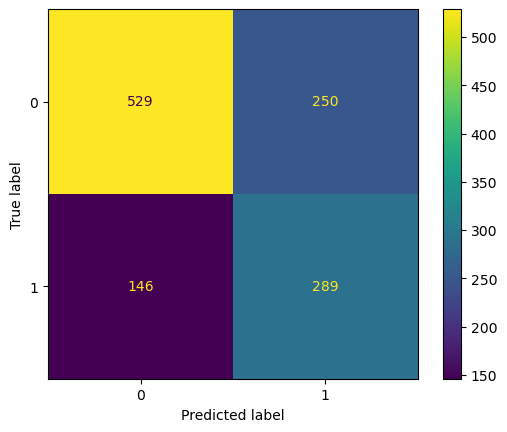

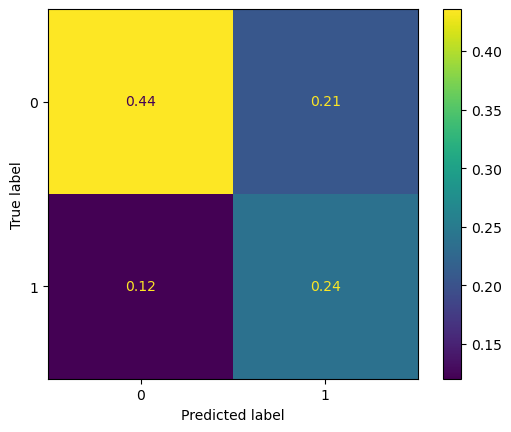

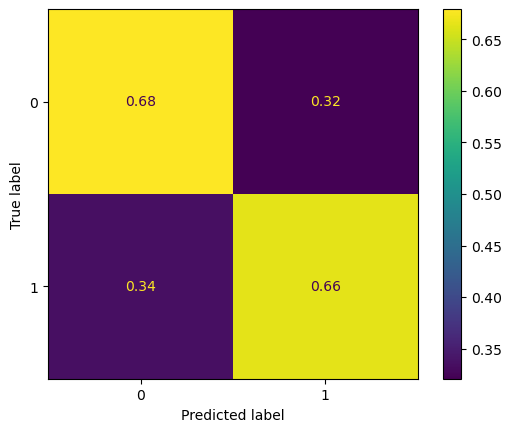




=== Race: other ===


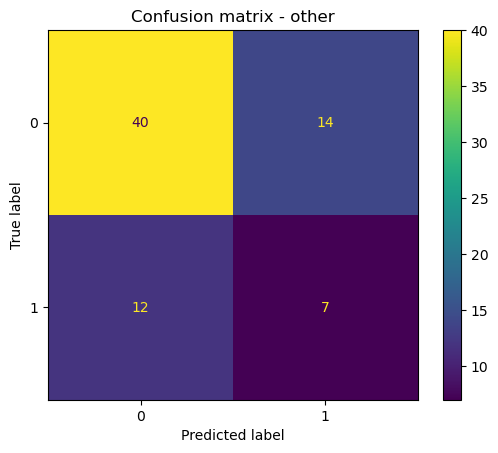

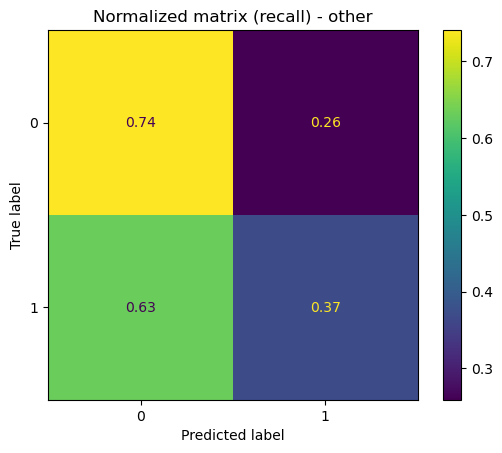


=== Race: african-american ===


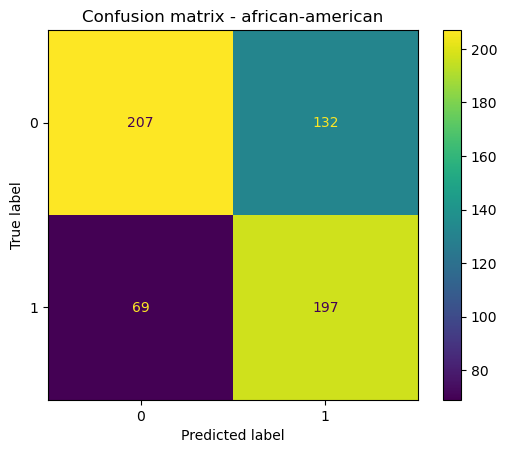

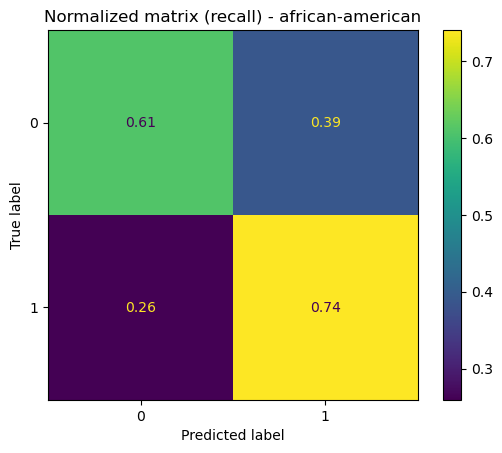


=== Race: hispanic ===


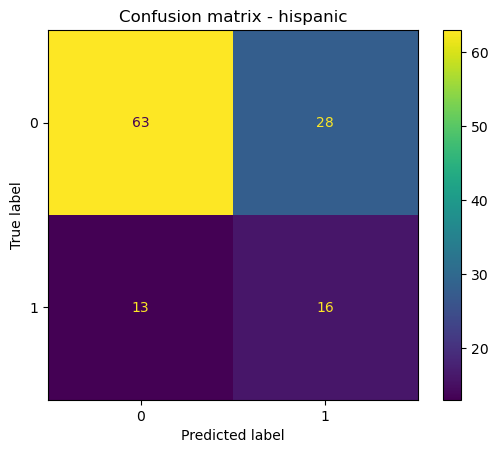

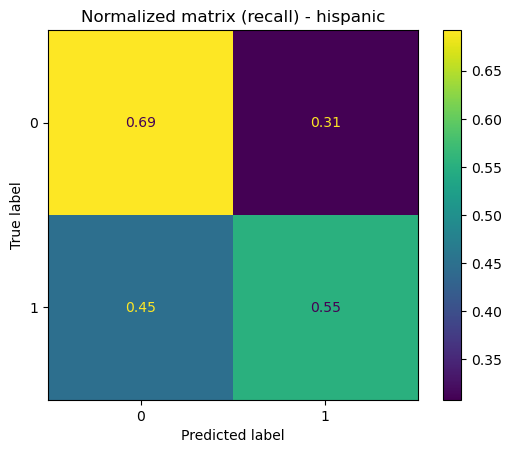


=== Race: caucasian ===


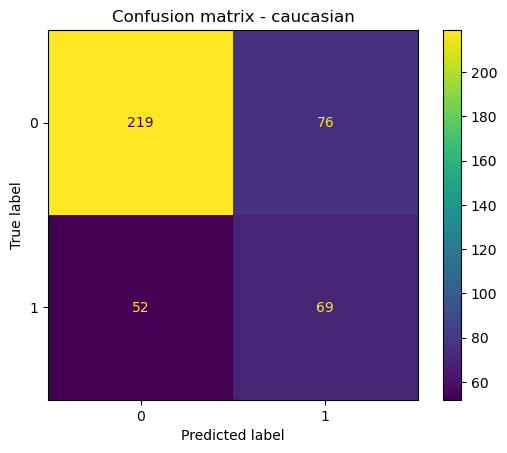

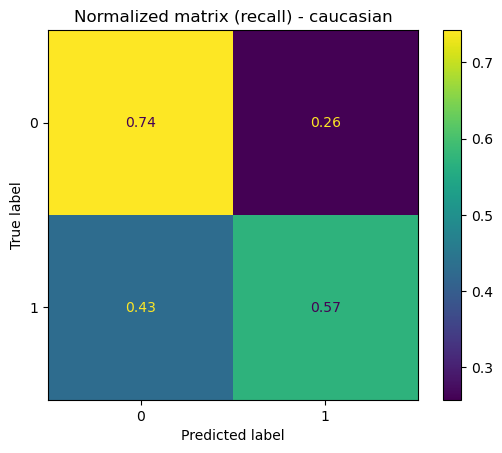

In [ ]:
X = no_outlier_df.drop(columns=drop_col_list)
y = no_outlier_df['two_year_recid']
race = no_outlier_df['race']

X_train, X_test, y_train, y_test, race_train, race_test= train_test_split(X, y, race, test_size = 0.2, random_state = 69, stratify = y)

# Weight by class
count = y_train.value_counts()
total = len(y_train)

weight_0 = total / (2 * count[0])
weight_1 = total / (2 * count[1])

w_class = y_train.map({
    0: weight_0,
    1: weight_1
})

# Weight by race

dist_race = race_train.value_counts(normalize=True)

weight_race = {r: 1 / np.sqrt(dist_race[r]) for r in dist_race.index}

w_race = race_train.map(weight_race)

# Final weight

w_train = w_class * w_race


model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

model.fit(X_train, y_train, sample_weight=w_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)


print("\nRanking report: ")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print(coefficients)

print("Confusion matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")


race_test = no_outlier_df.loc[X_test.index, 'race']

races = race_test.unique()

for race in races:
    idx = race_test == race
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Race: {race} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix (recall) - {race}")
    plt.show()

### Threshold por race - con reweighting


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.65      0.72       779
           1       0.53      0.69      0.60       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.67      1214

ROC AUC: 0.7324199902616086

Coeficientes:
               Variable  Coeficiente
13  adult_priors_freq_2    11.110241
1      juv_priors_count     0.362092
10   is_public_disorder     0.000000
4               is_drug     0.000000
11   is_justice_related    -0.000421
0                   age    -0.028379
9             is_sexual    -0.099820
5           is_property    -0.136882
7             is_weapon    -0.156867
12            no_charge    -0.180787
2       c_charge_degree    -0.202763
3            is_violent    -0.229278
6              is_fraud    -0.248283
8            is_traffic    -0.294881


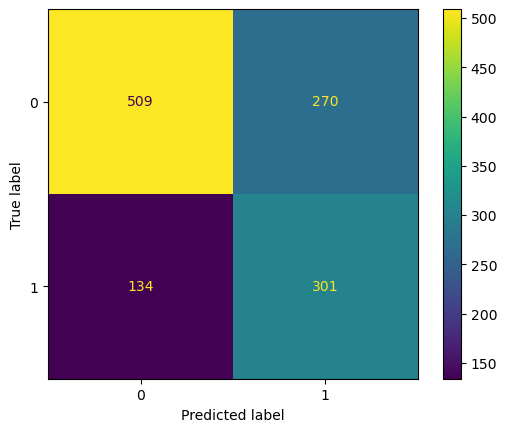

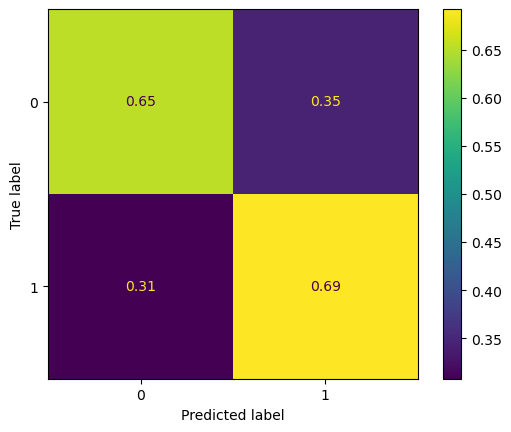


=== Race: other ===


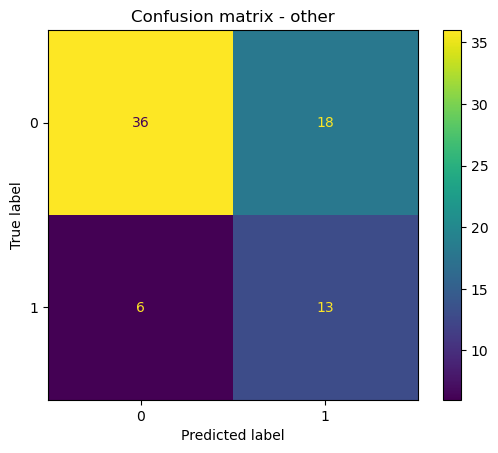

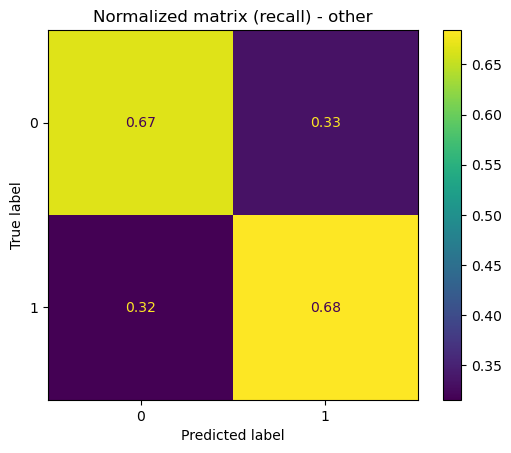


=== Race: african-american ===


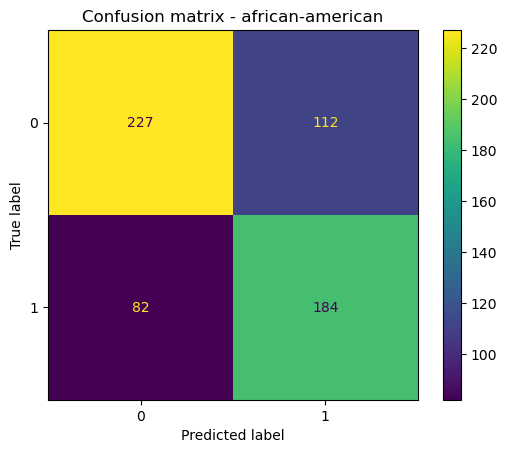

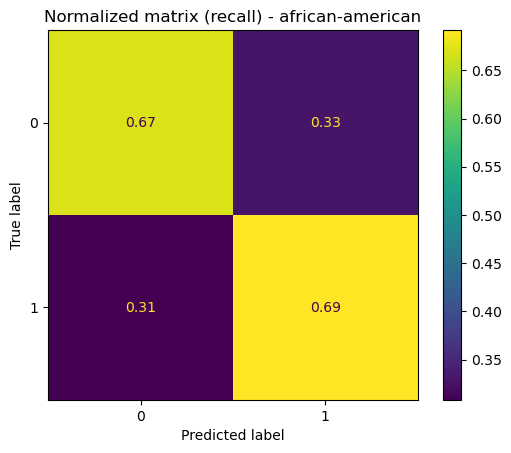


=== Race: hispanic ===


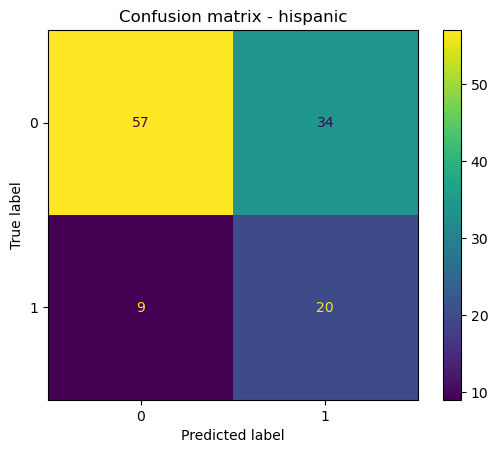

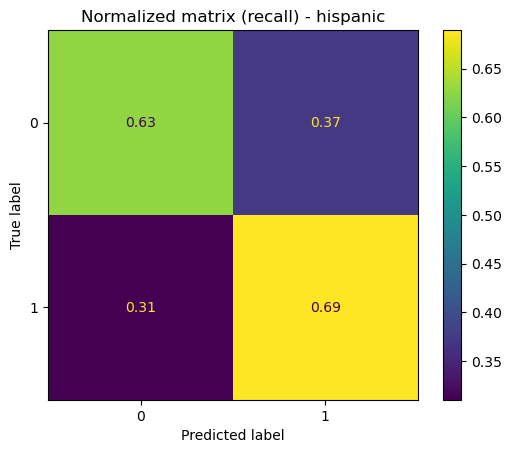


=== Race: caucasian ===


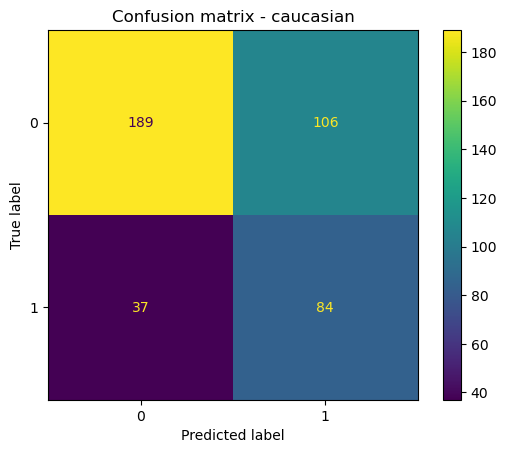

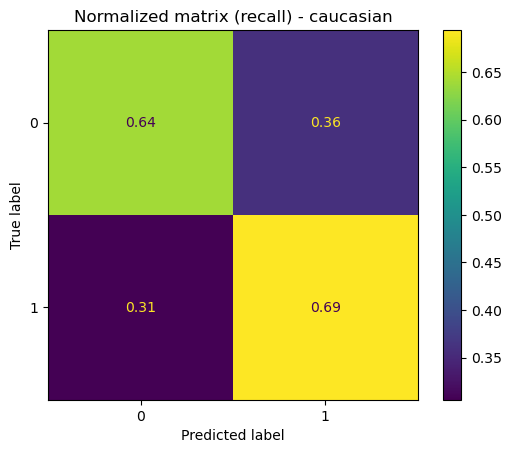

In [ ]:
X = no_outlier_df.drop(columns=drop_col_list)
y = no_outlier_df['two_year_recid']
race = no_outlier_df['race']


X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race,
    test_size=0.2,
    random_state=69,
    stratify=y
)

# -------------------------
# 2. WEIGHT BY CLASS
# -------------------------
count = y_train.value_counts()
total = len(y_train)

weight_0 = total / (2 * count[0])
weight_1 = total / (2 * count[1])

w_class = y_train.map({0: weight_0, 1: weight_1})

# -------------------------
# 3. WEIGHT BY RACE
# -------------------------
dist_race = race_train.value_counts(normalize=True)

weight_race = {r: 1 / np.sqrt(dist_race[r]) for r in dist_race.index}
w_race = race_train.map(weight_race)

# -------------------------
# 4. FINAL WEIGHT
# -------------------------
w_train = w_class * w_race

# -------------------------
# 5. MODEL
# -------------------------
model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')
model.fit(X_train, y_train, sample_weight=w_train)

# -------------------------
# 6. PROBABILITIES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 7. DATAFRAME EVALUATION
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'race': race_test
})

df_eval['y_score'] = y_proba

# -------------------------
# 8. THRESHOLD BY RACE
# -------------------------
thresholds = {
    'african-american': 0.52,
    'caucasian': 0.42,
    'hispanic': 0.44,
    'other': 0.45
}

def apply_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(apply_threshold, axis=1)
y_pred = df_eval['y_pred'].values

# -------------------------
# 9. OVERALL RESULTS
# -------------------------

print("\nRanking report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 10. COEFFICIENTS
# -------------------------
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print("\Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

# -------------------------
# 11. GLOBAL OVERVIEW
# -------------------------
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")

plt.show()

# -------------------------
# 12. FAIRNESS BY RACE
# -------------------------
for race in races:
    idx = race_test == race
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Race: {race} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix (recall) - {race}")
    plt.show()

    # # FPR
    # fp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 0)).sum()
    # tn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 0)).sum()
    # fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # # TPR
    # tp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 1)).sum()
    # fn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 1)).sum()
    # tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

### Modelo v.2.0 - Adversarial

In [ ]:
# # -------------------------
# # 1. COPY DATASET
# # -------------------------
# df_aif = no_outlier_df.copy()

# race_original = no_outlier_df['race']

# # -------------------------
# # 2. CREATE A BINARY VARIABLE FOR RACE
# # (choose the criteria you want)
# # -------------------------
# df_aif['race_binary'] = (df_aif['race'] == 'african-american').astype(int)

# # -------------------------
# # 3. DELETE original race
# # -------------------------
# df_aif = df_aif.drop(columns=['race'])

# # -------------------------
# # 4. CONVERT ALL TO NUMERIC
# # -------------------------
# df_aif = pd.get_dummies(df_aif, drop_first=True)

# # -------------------------
# # 5. SPLIT
# # -------------------------
# df_train, df_test, race_train_orig, race_test_orig = train_test_split(
#     df_aif,
#     race_original,
#     test_size=0.2,
#     random_state=69,
#     stratify=df_aif['two_year_recid']
# )

# # -------------------------
# # 6. CREATE DATASETS AIF360
# # -------------------------
# train_dataset = BinaryLabelDataset(
#     df=df_train,
#     label_names=['two_year_recid'],
#     protected_attribute_names=['race_binary']
# )

# test_dataset = BinaryLabelDataset(
#     df=df_test,
#     label_names=['two_year_recid'],
#     protected_attribute_names=['race_binary']
# )

# # -------------------------
# # 7. DEFINE GROUPS
# # -------------------------
# privileged_groups = [{'race_binary': 1}]
# unprivileged_groups = [{'race_binary': 0}]

# # -------------------------
# # 8. ADVERSARIAL MODEL
# # -------------------------

# import sys
# import tensorflow.compat.v1 as tf

# sys.modules['tensorflow'] = tf
# tf.disable_eager_execution()

# tf.compat.v1.disable_eager_execution()

# tf.compat.v1.reset_default_graph()

# sess = tf.compat.v1.Session()

# model_adv = AdversarialDebiasing(
#     privileged_groups=privileged_groups,
#     unprivileged_groups=unprivileged_groups,
#     scope_name='debiasing',
#     debias=True,
#     sess=sess
# )

# model_adv.fit(train_dataset)

# # -------------------------
# # 9. PREDICTION
# # -------------------------
# pred_dataset = model_adv.predict(test_dataset)

# y_pred_adv = pred_dataset.labels.ravel()
# y_true = test_dataset.labels.ravel()
# y_scores_adv = pred_dataset.scores.ravel()

# print("Confusion matrix:")
# print(confusion_matrix(y_true, y_pred_adv))

# print("\nRanking report:")
# print(classification_report(y_true, y_pred_adv))

# print("ROC AUC:", roc_auc_score(y_true, y_scores_adv))

# df_eval = df_test.copy()
# df_eval['y_true'] = y_true
# df_eval['y_pred'] = y_pred_adv
# df_eval['race'] = race_test_orig.values

# # FPR por race
# for r in df_eval['race'].unique():
#     grupo = df_eval[df_eval['race'] == r]
    
#     fp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 0)).sum()
#     tn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 0)).sum()
    
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
#     print(f"Race {r} - FPR: {fpr:.3f}")

### FairLearn

In [ ]:
# # -------------------------
# # 1. Data
# # -------------------------
# X = no_outlier_df.drop(columns=drop_col_list)
# y = no_outlier_df['two_year_recid']
# race = no_outlier_df['race']

# X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
#     X, y, race,
#     test_size=0.2,
#     random_state=69,
#     stratify=y
# )

# # -------------------------
# # 2. Base model (REVISED)
# # -------------------------
# base_model = LogisticRegression(
#     max_iter=1000,
#     penalty='l2', 
#     solver='lbfgs'
# )

# # -------------------------
# # 3. Fairlearn
# # -------------------------
# fair_model = ExponentiatedGradient(
#     estimator=base_model,
#     constraints=DemographicParity(),
#     eps=0.1
# )

# fair_model.fit(X_train, y_train, sensitive_features=race_train)

# # -------------------------
# # 4. Probabilities
# # -------------------------
# y_scores = fair_model._pmf_predict(X_test)[:, 1]

# print("min:", y_scores.min())
# print("max:", y_scores.max())
# print("mean:", y_scores.mean())

# # -------------------------
# # 5. Threshold tuning
# # -------------------------
# for t in [0.2, 0.3, 0.4, 0.5]:
#     y_pred_tmp = (y_scores >= t).astype(int)
#     print(f"\nThreshold {t}")
#     print(confusion_matrix(y_test, y_pred_tmp))

# threshold = 0.3
# y_pred_fair = (y_scores >= threshold).astype(int)

# # -------------------------
# # 6. Coefficient
# # -------------------------
# best_model = fair_model.predictors_[np.argmax(fair_model.weights_)]

# coefficients = pd.DataFrame({
#     'Variable': X.columns,
#     'Coefficient': best_model.coef_[0]
# })

# print(coefficients.sort_values(by='Coefficients', ascending=False))

# # -------------------------
# # 7. Overall results
# # -------------------------
# print("\nConfusion matrix")
# disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_fair))
# disp.plot()

# plt.show()

# print("\nRanking reports:")
# print(classification_report(y_test, y_pred_fair))

# # -------------------------
# # 8. Race results:
# # -------------------------
# y_pred_series = pd.Series(y_pred_fair, index=y_test.index)

# for race in race_test.unique():
#     idx = race_test == race
    
#     y_true_r = y_test.loc[idx]
#     y_pred_r = y_pred_series.loc[idx]
    
#     print(f"\n=== Race: {race} ===")
    
#     cm = confusion_matrix(y_true_r, y_pred_r)
#     ConfusionMatrixDisplay(cm).plot()
#     plt.title(f"Matriz - {race}")
#     plt.show()
    
#     cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
#     ConfusionMatrixDisplay(cm_norm).plot()
#     plt.title(f"Recall - {race}")
#     plt.show()

### Threshold por race - sin reweighting

In [31]:
drop_col_list = ['two_year_recid', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq',
       'adult_priors_freq_3', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'total_priors_count',
       'log_juv_priors_count', 'log_adult_priors_count', "adult_priors_count", 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'sex', 'age_cat']

este es el bueno

In [32]:
from sklearn.preprocessing import StandardScaler

features_num = ['age', 'juv_priors_count', 'adult_priors_freq_2']
features_bin = ['is_public_disorder', 'is_justice_related', 'is_sexual', 'is_drug', 'is_weapon', 'is_property', 'c_charge_degree', 'no_charge', 'is_fraud', 'is_violent', 'is_traffic']

scaler = StandardScaler()
df_model_scaled = no_outlier_df.copy()
df_model_scaled[features_num] = scaler.fit_transform(no_outlier_df[features_num])



Coeficientes:
               Variable  Coeficiente
13  adult_priors_freq_2     0.676972
1      juv_priors_count     0.223406
10   is_public_disorder     0.000000
11   is_justice_related     0.000000
9             is_sexual    -0.014954
4               is_drug    -0.081451
7             is_weapon    -0.091060
5           is_property    -0.161602
2       c_charge_degree    -0.166820
12            no_charge    -0.198536
6              is_fraud    -0.266155
3            is_violent    -0.307165
8            is_traffic    -0.345158
0                   age    -0.357012

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       779
           1       0.54      0.68      0.60       435

    accuracy                           0.68      1214
   macro avg       0.67      0.68      0.67      1214
weighted avg       0.70      0.68      0.68      1214

ROC AUC: 0.7314933675652546


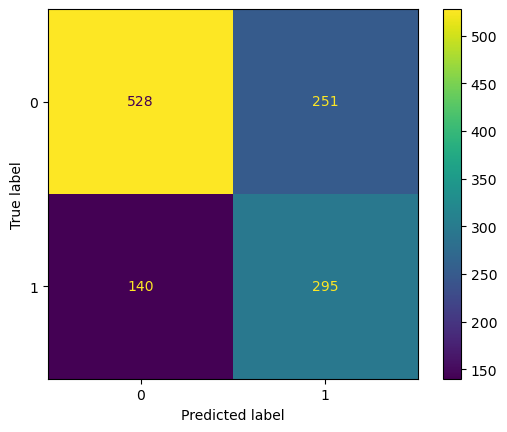

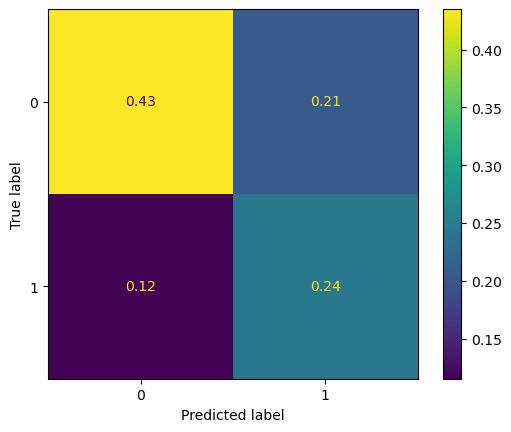

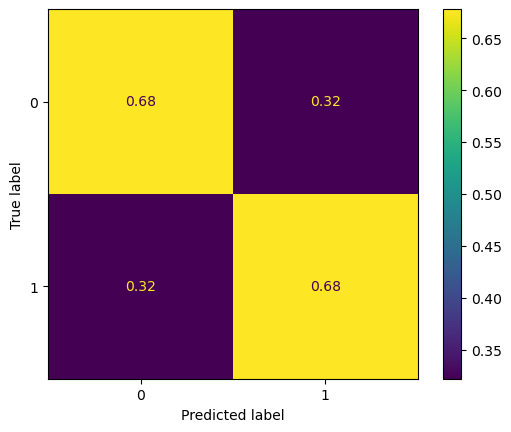


=== Raza: other ===


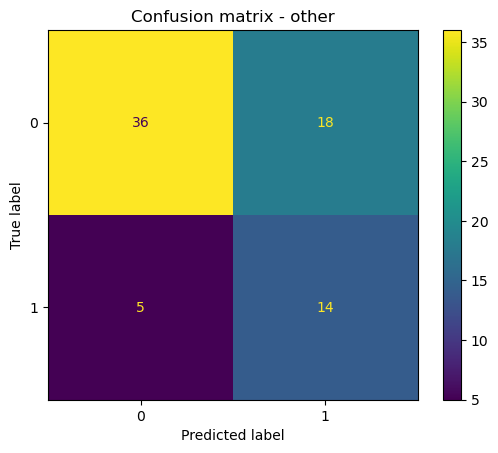

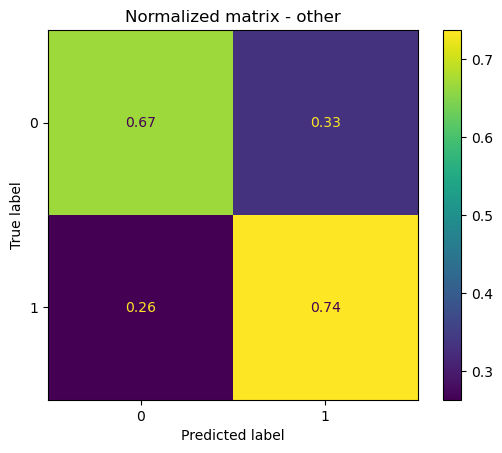

FPR: 0.333 | TPR: 0.737

=== Raza: african-american ===


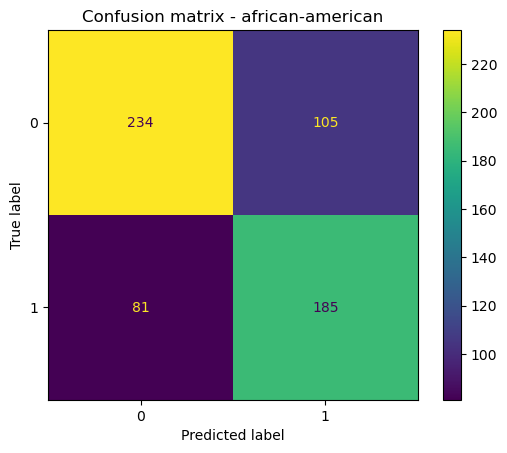

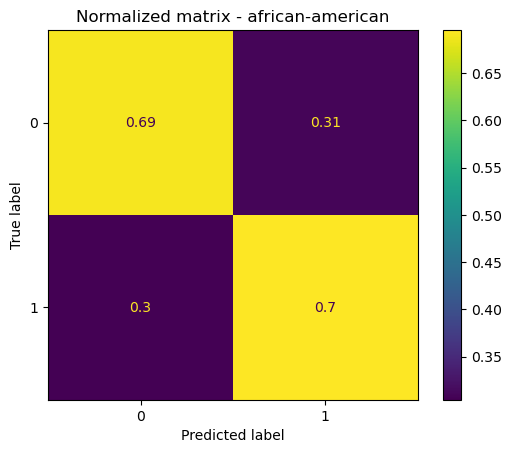

FPR: 0.310 | TPR: 0.695

=== Raza: hispanic ===


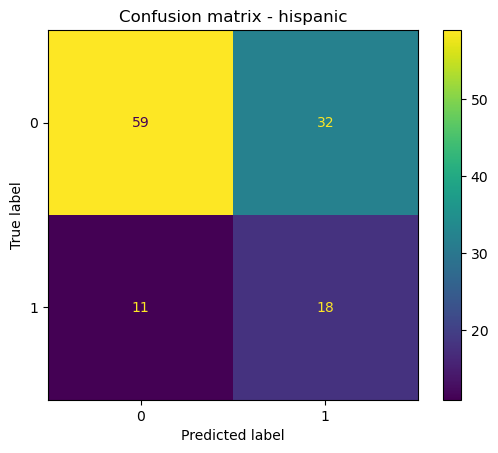

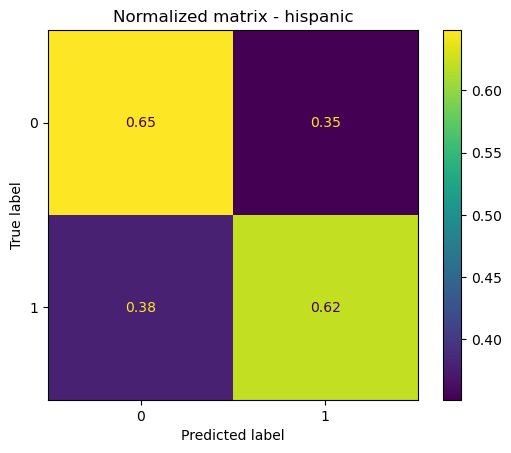

FPR: 0.352 | TPR: 0.621

=== Raza: caucasian ===


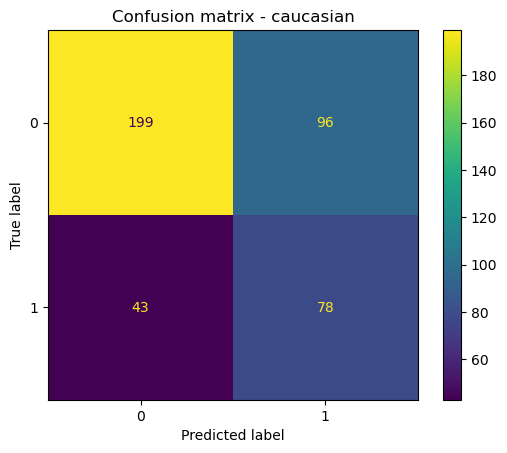

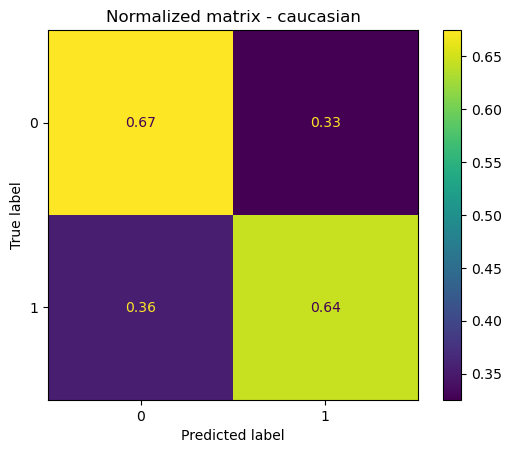

FPR: 0.325 | TPR: 0.645


In [ ]:

# -------------------------
# 1. DATA
# -------------------------
X = df_model_scaled.drop(columns=drop_col_list)
y = df_model_scaled['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)


person_id_test = X_test['person_id']

X_train = X_train.drop(columns=['person_id'])
X_test = X_test.drop(columns=['person_id'])

# -------------------------
# 2. MODEL
# -------------------------
model = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILITIES
# -------------------------
y_proba = pd.Series(
    model.predict_proba(X_test)[:, 1],
    index=X_test.index
)

# -------------------------
# 4. RACE (for fairness)
# -------------------------
df_aux = no_outlier_df.set_index('person_id')

race_test = df_aux.loc[person_id_test, 'race']
sex_test = df_aux.loc[person_id_test, 'sex']
age_cat_test = df_aux.loc[person_id_test, 'age_cat']

# -------------------------
# 5. DATAFRAME EVALUATION
# -------------------------
df_eval = pd.DataFrame(index=X_test.index)

df_eval['person_id'] = person_id_test.values
df_eval['y_true'] = y_test.values
df_eval['race'] = race_test.values
df_eval['sex'] = sex_test.values
df_eval['age_cat'] = age_cat_test.values
df_eval['y_score'] = y_proba.values

# -------------------------
# 6. THRESHOLD BY RACE
# -------------------------
thresholds = {
    'african-american': 0.53,
    'caucasian': 0.45,
    'hispanic': 0.46,
    'other': 0.45
}

def apply_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(apply_threshold, axis=1)

y_pred = df_eval['y_pred'].values

# -------------------------
# 7. COEFFICIENTS
# -------------------------
coefficients = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': model.coef_[0]
})

print("\Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

# -------------------------
# 8. IMPORTANCE OF VARIABLES
# -------------------------

print("\nRanking report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. GLOBAL OVERVIEW
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS BY RACE
# -------------------------
races = df_eval['race'].unique()

for race in races:
    group = df_eval[df_eval['race'] == race]
    
    y_true_r = group['y_true']
    y_pred_r = group['y_pred']
    
    print(f"\n=== Raza: {race} ===")
    
    # Normal matrix
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    # Normalized matrix
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix - {race}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

In [34]:
df_eval.isnull().sum()

person_id    0
y_true       0
race         0
sex          0
age_cat      0
y_score      0
y_pred       0
dtype: int64

In [35]:
df_eval.head()

,person_id,y_true,race,sex,age_cat,y_score,y_pred
3426,59474.0,0,other,0,25-45,0.435030,0
5708,59890.0,1,african-american,0,less than 25,0.490043,0
4509,61156.0,0,hispanic,0,less than 25,0.534627,1
3525,57039.0,0,caucasian,1,25-45,0.360676,0
5826,58070.0,1,other,0,less than 25,0.597147,1


In [36]:
df_eval.to_csv(r'..\00_Data\00_Processed\df_eval.csv', index=False)
no_outlier_df.to_csv(r'..\00_Data\00_Processed\no_outlier_df.csv', index=False)


Coeficientes:
               Variable  Coeficiente
14  adult_priors_freq_2     0.655648
2      juv_priors_count     0.221484
11   is_public_disorder     0.000000
12   is_justice_related     0.000000
0             person_id    -0.000004
10            is_sexual    -0.015883
5               is_drug    -0.087207
8             is_weapon    -0.092077
6           is_property    -0.163536
3       c_charge_degree    -0.170763
13            no_charge    -0.201190
7              is_fraud    -0.265506
4            is_violent    -0.307978
9            is_traffic    -0.344939
1                   age    -0.357951

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.67      0.72       779
           1       0.53      0.68      0.60       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.68      1214

ROC AUC: 0.7300193292314048


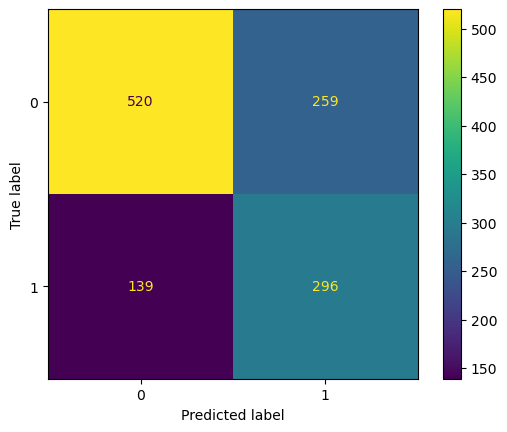

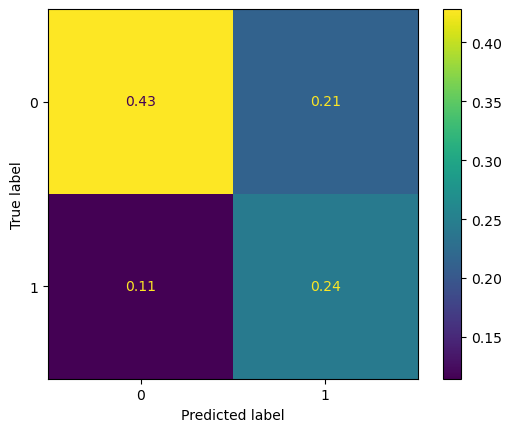

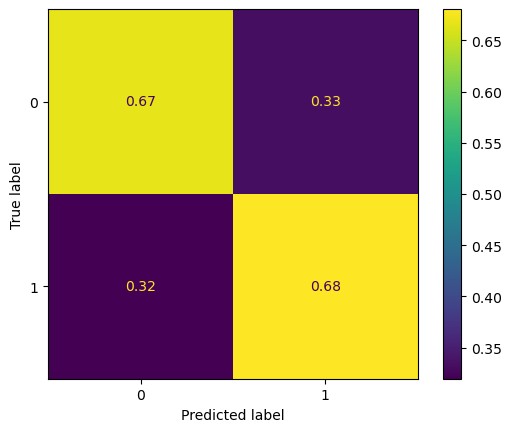


=== Raza: other ===


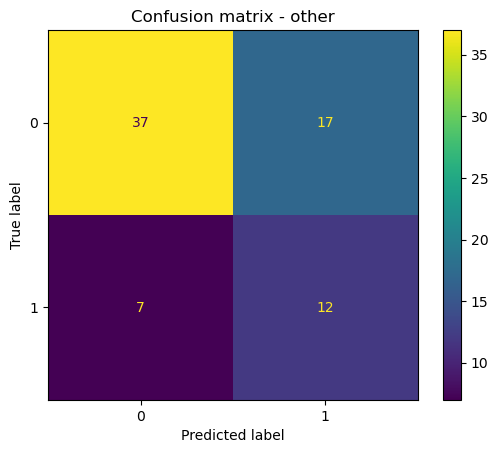

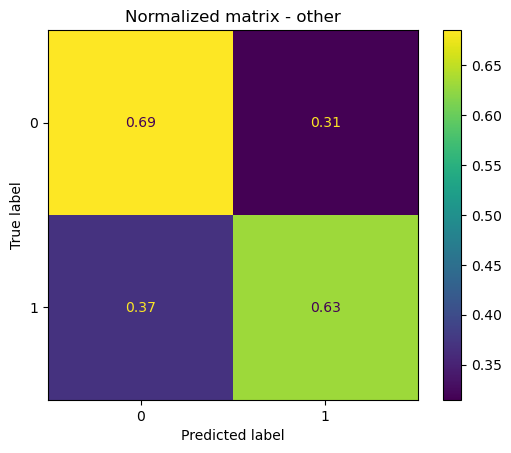

FPR: 0.315 | TPR: 0.632

=== Raza: african-american ===


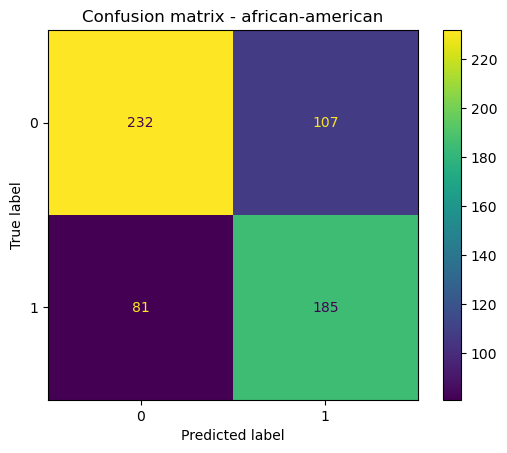

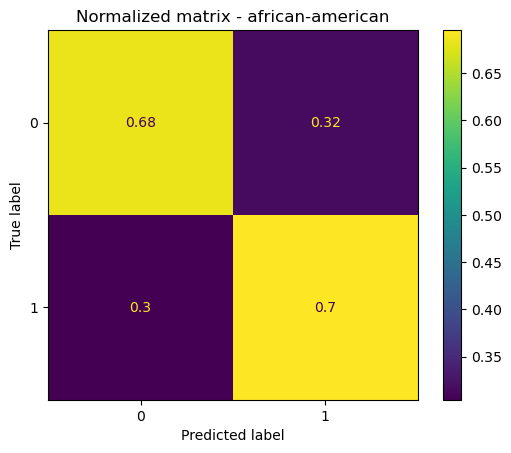

FPR: 0.316 | TPR: 0.695

=== Raza: hispanic ===


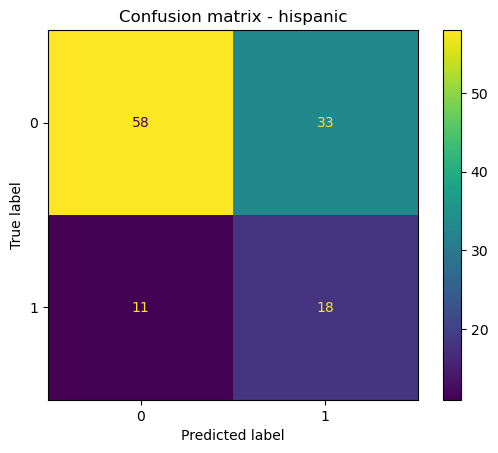

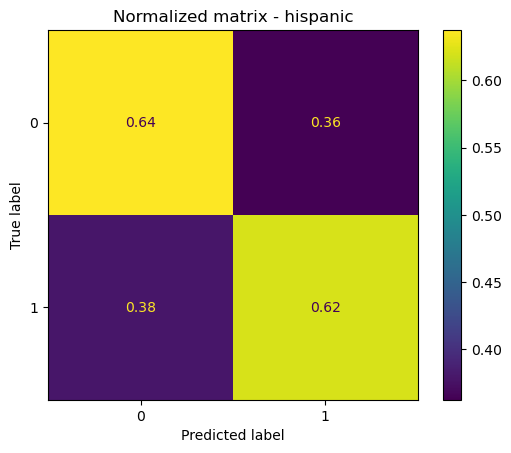

FPR: 0.363 | TPR: 0.621

=== Raza: caucasian ===


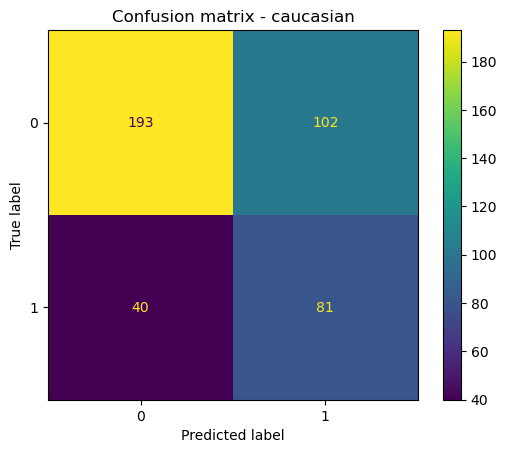

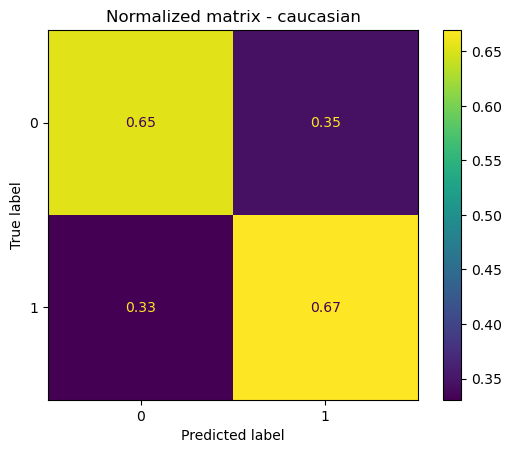

FPR: 0.346 | TPR: 0.669


In [ ]:
X = df_model_scaled.drop(columns=drop_col_list)
y = df_model_scaled['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODEL
# -------------------------
model = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILITIES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 4. RACE (for fairness)
# -------------------------
race_test = no_outlier_df.loc[X_test.index, 'race']

# -------------------------
# 5. DATAFRAME EVALUATION
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 6. THRESHOLD BY RACE
# -------------------------
thresholds = {
    'african-american': 0.53,
    'caucasian': 0.44,
    'hispanic': 0.46,
    'other': 0.47,
}

def apply_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(apply_threshold, axis=1)

y_pred = df_eval['y_pred'].values

# -------------------------
# 7. COEFFICIENTS
# -------------------------
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print("\Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

# -------------------------
# 8. IMPORTANCE OF VARIABLES
# -------------------------

print("\nRanking report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. GLOBAL OVERVIEW
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS BY RACE
# -------------------------
races = df_eval['race'].unique()

for race in races:
    group = df_eval[df_eval['race'] == race]
    
    y_true_r = group['y_true']
    y_pred_r = group['y_pred']
    
    print(f"\n=== Raza: {race} ===")
    
    # Normal matrix
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    # Normalized matrix
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix - {race}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

### Threshold por race - sin rw sin cb


Coeficientes:
               Variable  Coeficiente
14  adult_priors_freq_2     9.492815
2      juv_priors_count     0.342523
10            is_sexual     0.000000
12   is_justice_related     0.000000
11   is_public_disorder     0.000000
0             person_id    -0.000005
1                   age    -0.030813
8             is_weapon    -0.084368
5               is_drug    -0.095302
6           is_property    -0.160974
3       c_charge_degree    -0.171417
13            no_charge    -0.183492
7              is_fraud    -0.240882
4            is_violent    -0.322529
9            is_traffic    -0.347900

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.65      0.71       779
           1       0.52      0.68      0.59       435

    accuracy                           0.66      1214
   macro avg       0.65      0.67      0.65      1214
weighted avg       0.69      0.66      0.67      1214

ROC AUC: 0.7272099508653889


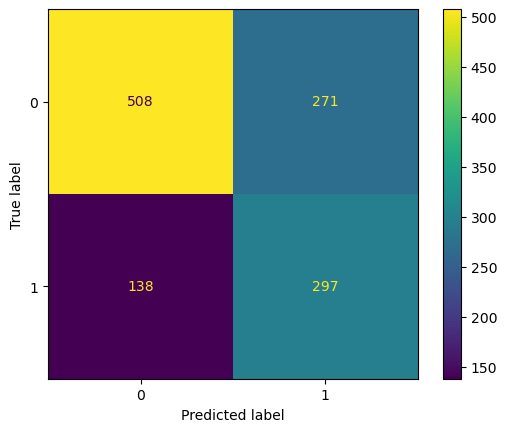

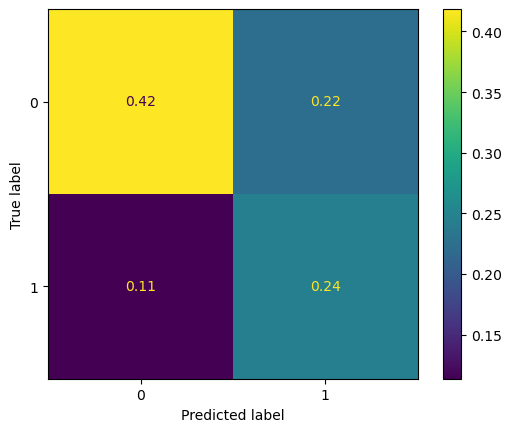

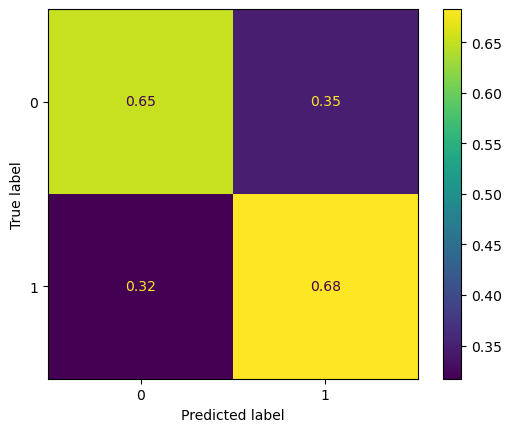


=== Raza: other ===


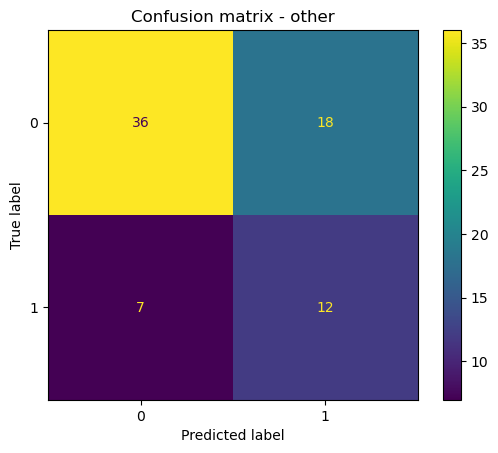

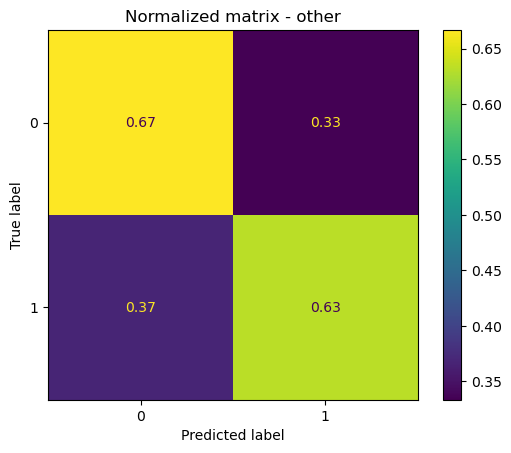

FPR: 0.333 | TPR: 0.632

=== Raza: african-american ===


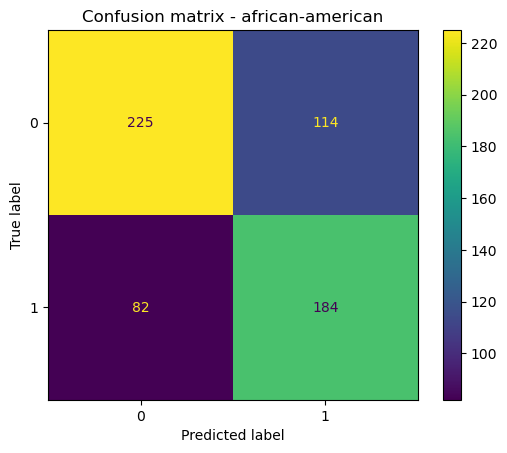

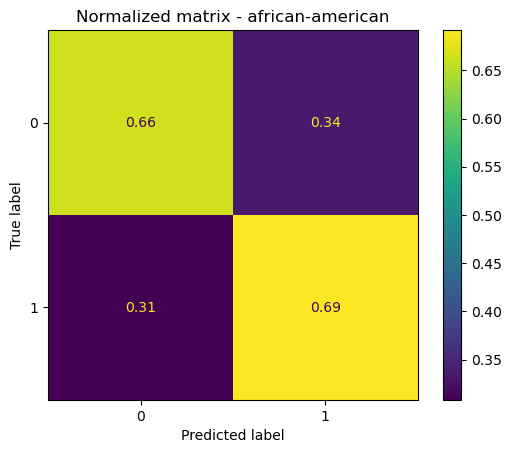

FPR: 0.336 | TPR: 0.692

=== Raza: hispanic ===


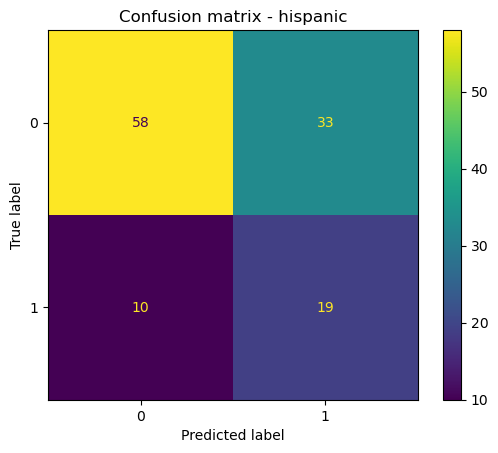

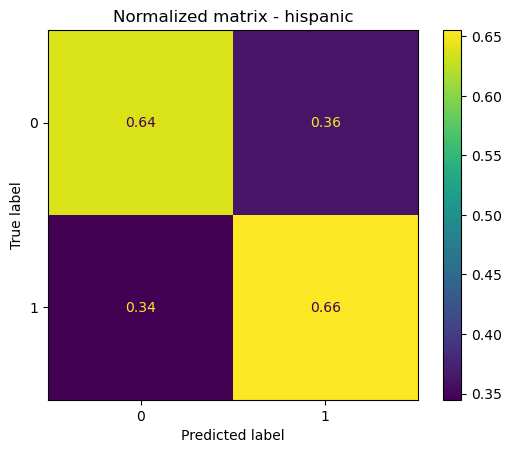

FPR: 0.363 | TPR: 0.655

=== Raza: caucasian ===


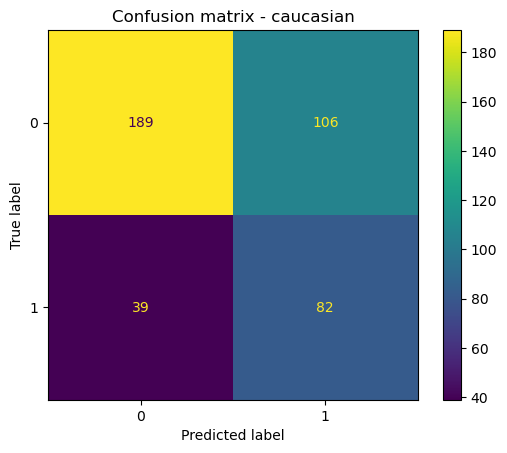

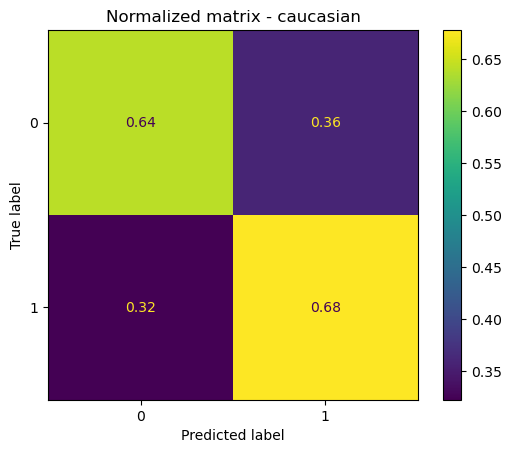

FPR: 0.359 | TPR: 0.678


In [ ]:
X = no_outlier_df.drop(columns=drop_col_list)
y = no_outlier_df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODEL
# -------------------------
model = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='liblinear'
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILITIES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 4. RACE (for fairness)
# -------------------------
race_test = no_outlier_df.loc[X_test.index, 'race']

# -------------------------
# 5. DATAFRAME EVALUATION
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 6. THRESHOLD BY RACE
# -------------------------
thresholds = {
    'african-american': 0.39,
    'caucasian': 0.3,
    'hispanic': 0.323,
    'other': 0.325
}

def apply_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(apply_threshold, axis=1)

y_pred = df_eval['y_pred'].values

# -------------------------
# 7. COEFFICIENT
# -------------------------
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print("\Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

# -------------------------
# 8. OVERALL RESULTS
# -------------------------

print("\nRanking report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. GLOBAL OVERVIEW
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS BY RACE
# -------------------------
races = df_eval['race'].unique()

for race in races:
    group = df_eval[df_eval['race'] == race]
    
    y_true_r = group['y_true']
    y_pred_r = group['y_pred']
    
    print(f"\n=== Raza: {race} ===")
    
    # Normal matrix
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    # Normalized matrix
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix - {race}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

### Modelo v.2.0 - Arbol de decisión

controlando por race


Importancia de variables:
               Variable  Importancia
14  adult_priors_freq_2     0.642893
1                   age     0.233615
2      juv_priors_count     0.058737
9            is_traffic     0.021796
0             person_id     0.018500
13            no_charge     0.012735
5               is_drug     0.008701
4            is_violent     0.003023
3       c_charge_degree     0.000000
6           is_property     0.000000
7              is_fraud     0.000000
10            is_sexual     0.000000
8             is_weapon     0.000000
12   is_justice_related     0.000000
11   is_public_disorder     0.000000

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.63      0.70       779
           1       0.51      0.71      0.60       435

    accuracy                           0.65      1214
   macro avg       0.65      0.67      0.65      1214
weighted avg       0.69      0.65      0.66      1214

ROC AUC: 0.722858660528529


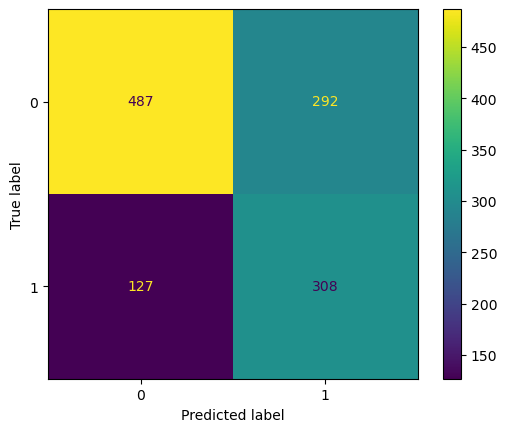

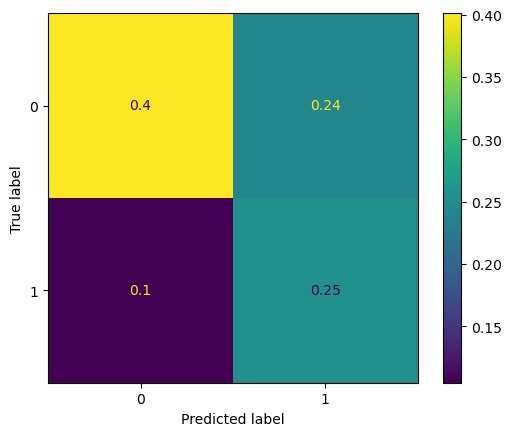

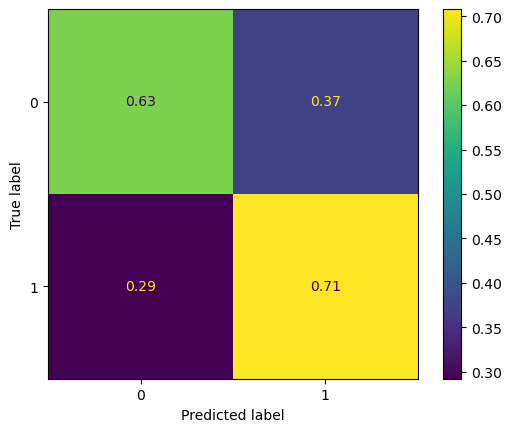


=== Raza: other ===


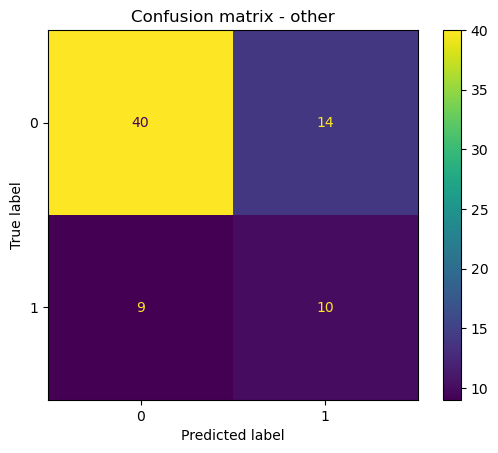

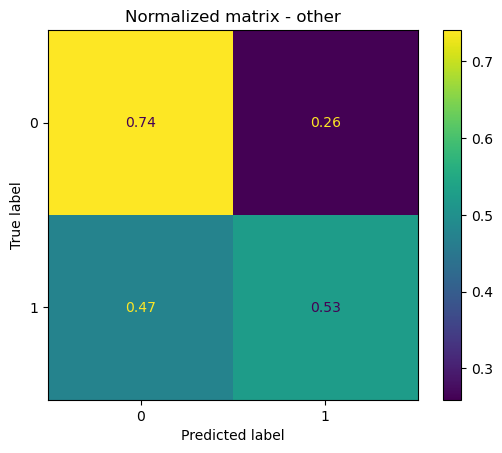

FPR: 0.259 | TPR: 0.526

=== Raza: african-american ===


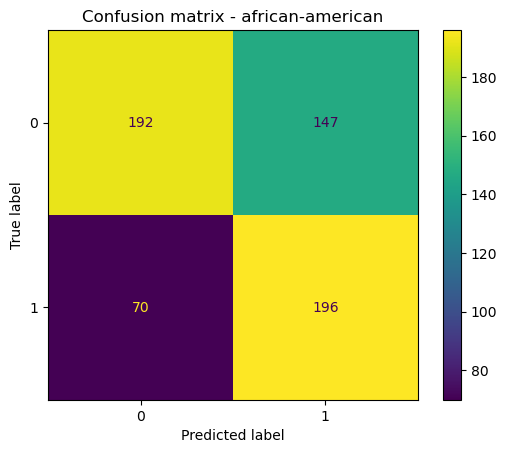

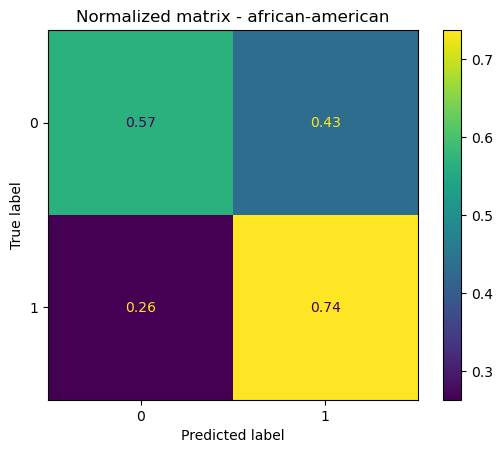

FPR: 0.434 | TPR: 0.737

=== Raza: hispanic ===


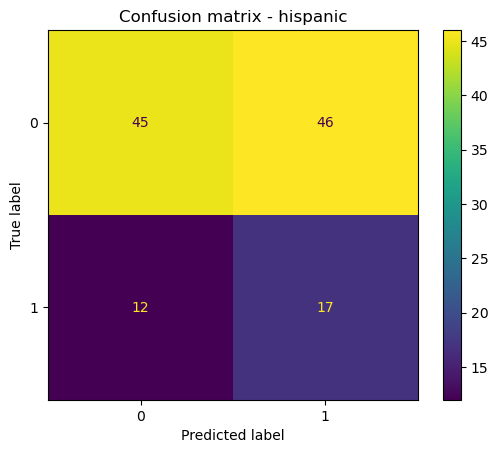

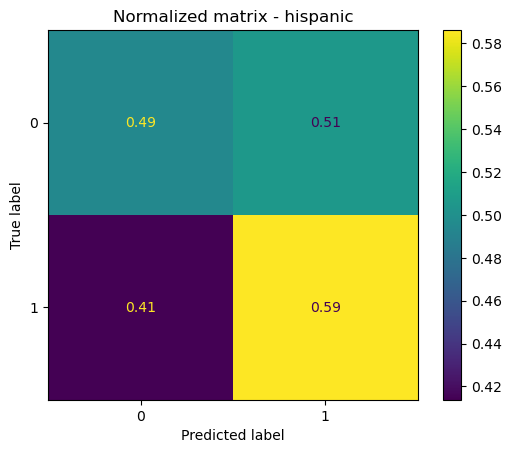

FPR: 0.505 | TPR: 0.586

=== Raza: caucasian ===


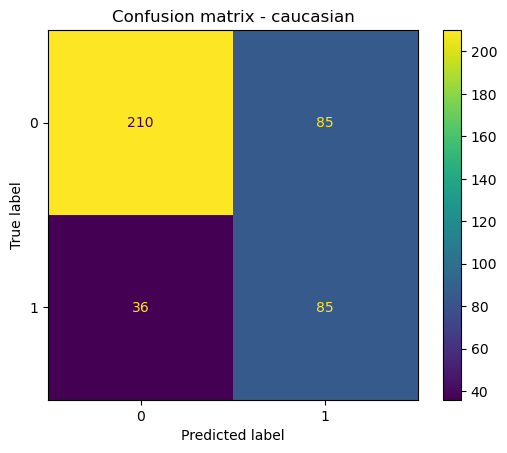

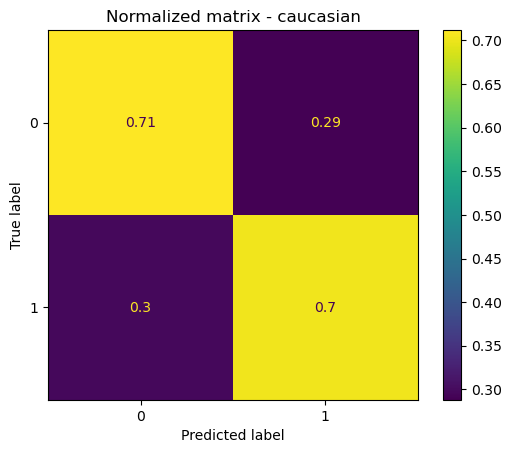

FPR: 0.288 | TPR: 0.702


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------
# 1. DATA
# -------------------------
X = no_outlier_df.drop(columns=drop_col_list)
y = no_outlier_df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODEL (TREE)
# -------------------------
model = DecisionTreeClassifier(
    max_depth=5,        
    min_samples_leaf=20,     
    class_weight='balanced', 
    random_state=69
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILITIES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 4. RACE
# -------------------------
race_test = no_outlier_df.loc[X_test.index, 'race']

# -------------------------
# 5. DATAFRAME EVALUATION
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 6. THRESHOLD BY RACE
# -------------------------
thresholds = {
    'african-american': 0.5,
    'caucasian': 0.45,
    'hispanic': 0.3625,
    'other': 0.47
}

def apply_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(apply_threshold, axis=1)
y_pred = df_eval['y_pred'].values

# -------------------------
# 7.IMPORTANCE OF VARIABLES
# -------------------------
significances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
})

print("\nImportancia de variables:")
print(significances.sort_values(by='Importancia', ascending=False))

# -------------------------
# 8. OVERALL RESULTS
# -------------------------

print("\nRanking report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. GLOBAL OVERVIEW
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS BY RACE
# -------------------------
races = df_eval['race'].unique()

for race in races:
    group = df_eval[df_eval['race'] == race]
    
    y_true_r = group['y_true']
    y_pred_r = group['y_pred']
    
    print(f"\n=== Race: {race} ===")
    
    # Normal matrix
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    # Normalized matrix
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix - {race}")
    plt.show()
    
    # FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.68      0.73       779
           1       0.53      0.65      0.59       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.69      0.67      0.68      1214

ROC AUC: 0.7262493913505377

Importancia de variables:
               Variable  Importancia
14  adult_priors_freq_2     0.749127
1                   age     0.125828
2      juv_priors_count     0.033659
0             person_id     0.031986
13            no_charge     0.031540
3       c_charge_degree     0.014451
9            is_traffic     0.013409
6           is_property     0.000000
5               is_drug     0.000000
4            is_violent     0.000000
7              is_fraud     0.000000
10            is_sexual     0.000000
8             is_weapon     0.000000
12   is_justice_related     0.000000
11   is_public_disorder     0.000000

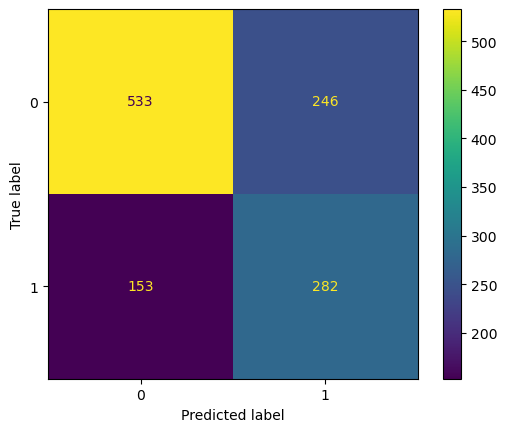

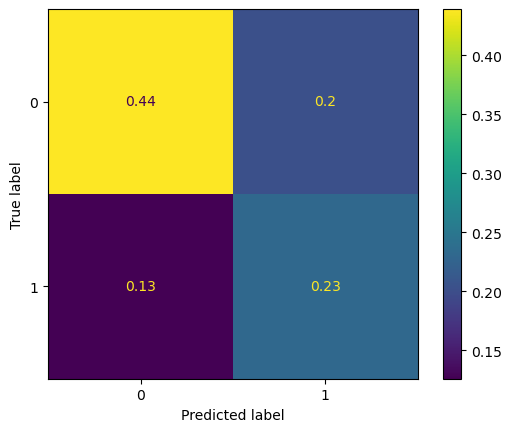

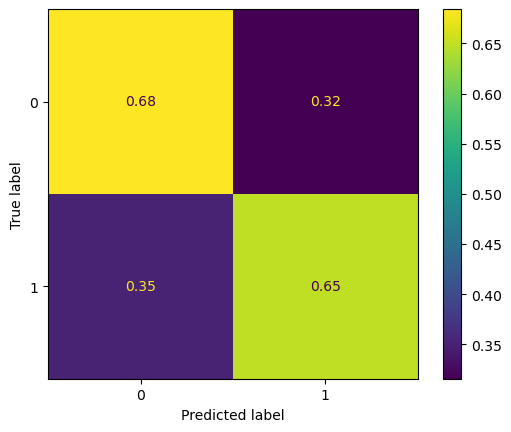


=== Raza: other ===


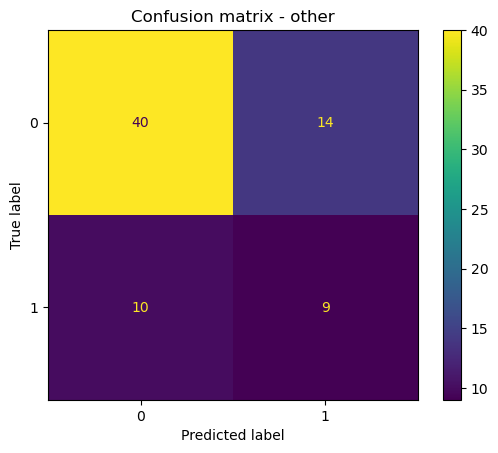

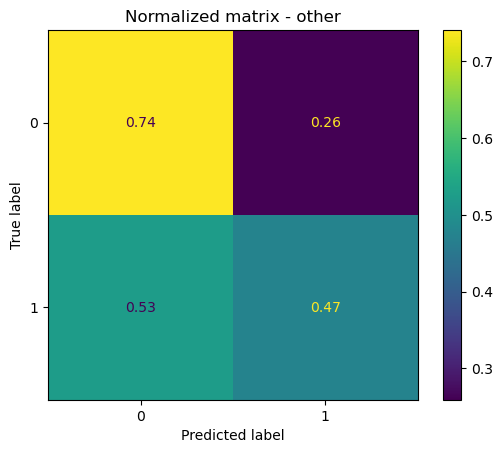

FPR: 0.259 | TPR: 0.474

=== Raza: african-american ===


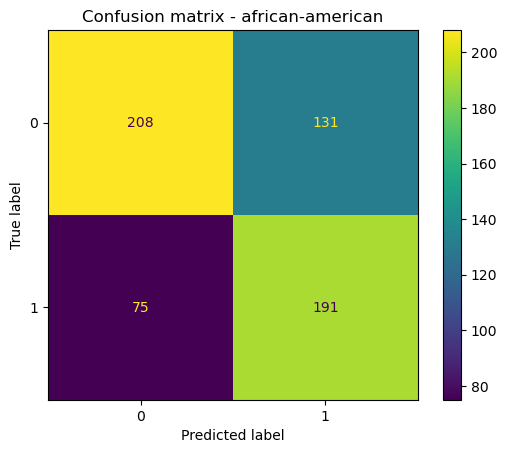

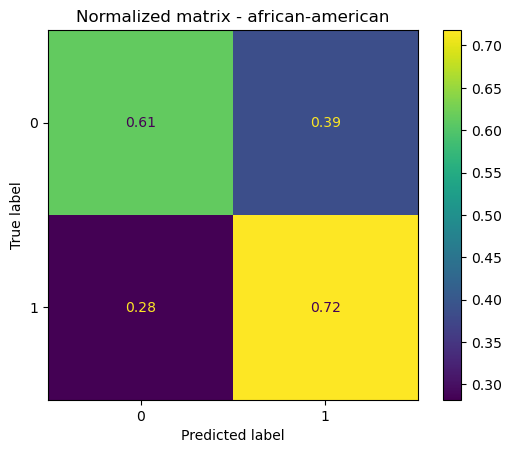

FPR: 0.386 | TPR: 0.718

=== Raza: hispanic ===


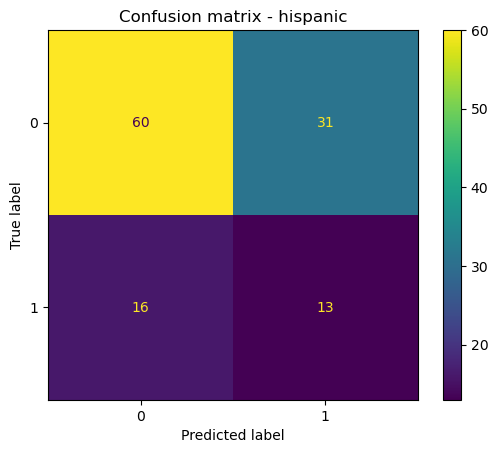

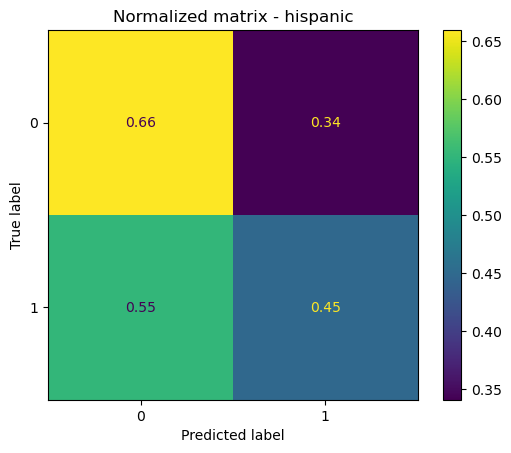

FPR: 0.341 | TPR: 0.448

=== Raza: caucasian ===


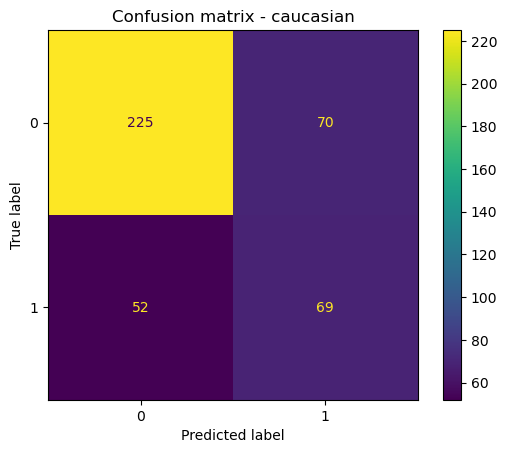

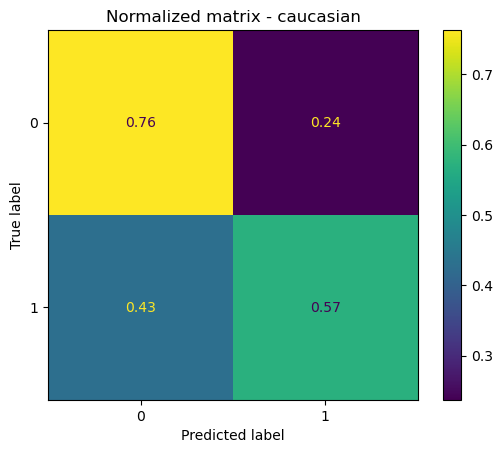

FPR: 0.237 | TPR: 0.570


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------
# 1. DATA
# -------------------------
X = no_outlier_df.drop(columns=drop_col_list)
y = no_outlier_df['two_year_recid']
race = no_outlier_df['race']

X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race,
    test_size=0.2,
    random_state=69,
    stratify=y
)

# -------------------------
# 2. WEIGHTS BY CLASS
# -------------------------
count = y_train.value_counts()
total = len(y_train)

weight_0 = total / (2 * count[0])
weight_1 = total / (2 * count[1])

w_class = y_train.map({
    0: weight_0,
    1: weight_1
})

# -------------------------
# 3. WEIGHTS BY RACE
# -------------------------
dist_race = race_train.value_counts(normalize=True)

weight_race = {r: 1 / np.sqrt(dist_race[r]) for r in dist_race.index}

w_race = race_train.map(weight_race)

# -------------------------
# 4. FINAL WEIGHT
# -------------------------
w_train = w_class * w_race

# -------------------------
# 5. MODEL (TREE)
# -------------------------
model = DecisionTreeClassifier(
    max_depth=5,           # 👈 importante para estabilidad
    min_samples_leaf=20,   # 👈 evita overfitting
    random_state=69
)

model.fit(X_train, y_train, sample_weight=w_train)

# -------------------------
# 6. PREDICTIONS
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# -------------------------
# 7. OVERALL RESULTS
# -------------------------

print("\nRanking report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 8. IMPORTANCE OF VARIABLES
# -------------------------
significances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
})

print("\nImportancia de variables:")
print(significances.sort_values(by='Importance', ascending=False))

# -------------------------
# 9. GLOBAL OVERVIEW
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS BY RACE
# -------------------------
race_test = no_outlier_df.loc[X_test.index, 'race']

for race in race_test.unique():
    idx = race_test == race
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {race} ===")
    
    # Normal matrix
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    # Normalized matrix
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix - {race}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.66      0.72       779
           1       0.53      0.68      0.60       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.68      1214

ROC AUC: 0.722858660528529

Importancia de variables:
               Variable  Importancia
14  adult_priors_freq_2     0.642893
1                   age     0.233615
2      juv_priors_count     0.058737
9            is_traffic     0.021796
0             person_id     0.018500
13            no_charge     0.012735
5               is_drug     0.008701
4            is_violent     0.003023
3       c_charge_degree     0.000000
6           is_property     0.000000
7              is_fraud     0.000000
10            is_sexual     0.000000
8             is_weapon     0.000000
12   is_justice_related     0.000000
11   is_public_disorder     0.000000


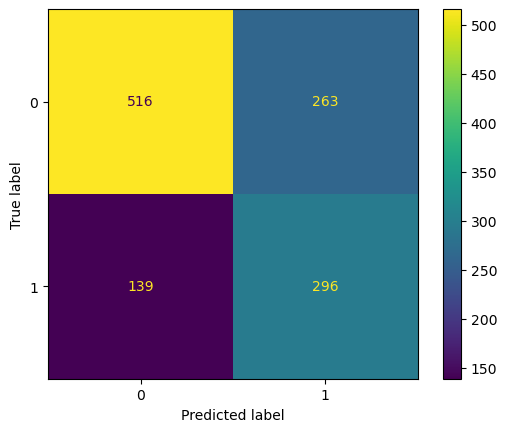

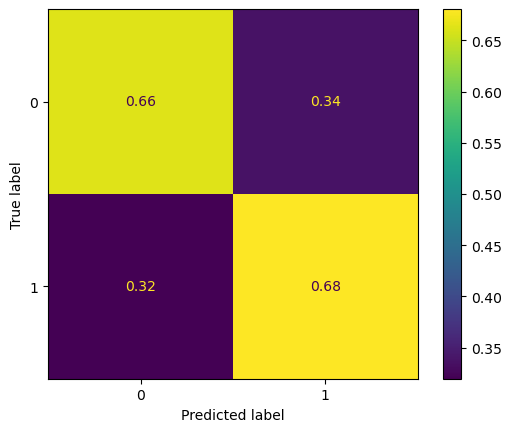


=== Raza: african-american ===


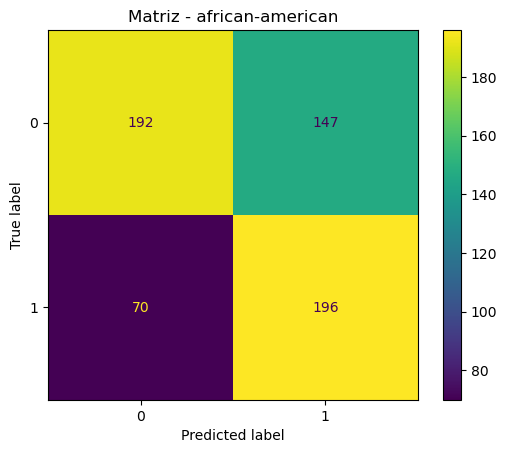

FPR: 0.434 | TPR: 0.737

=== Raza: caucasian ===


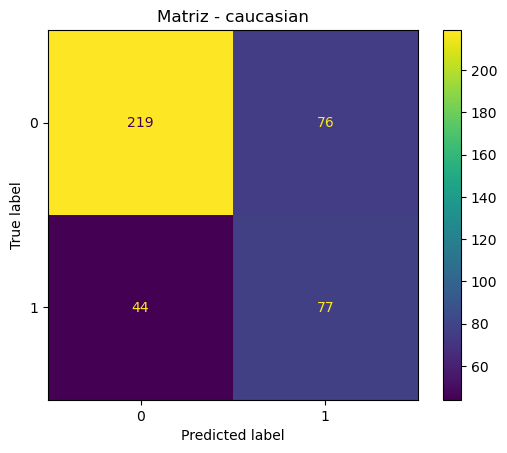

FPR: 0.258 | TPR: 0.636

=== Raza: hispanic ===


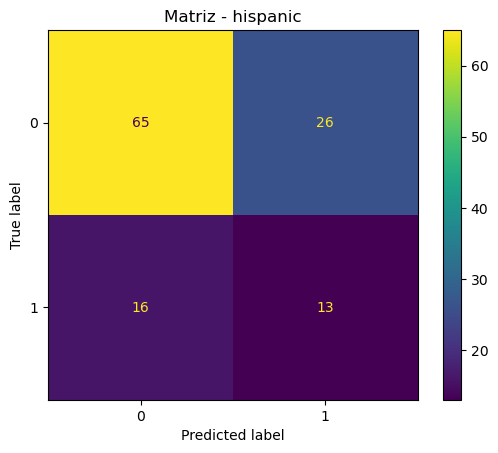

FPR: 0.286 | TPR: 0.448

=== Raza: other ===


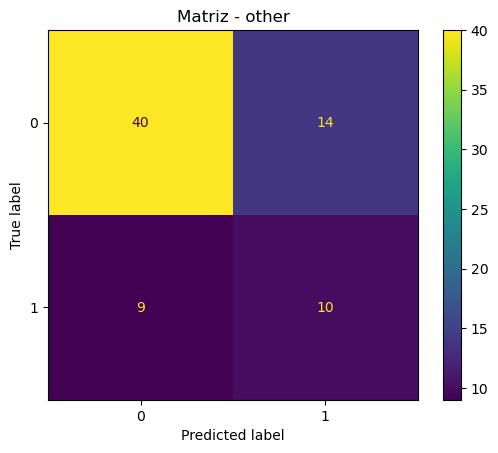

FPR: 0.259 | TPR: 0.526


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------
# 1. DATA
# -------------------------
X = no_outlier_df.drop(columns=drop_col_list)
y = no_outlier_df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODEL (TREE)
# -------------------------
model = DecisionTreeClassifier(
    max_depth=5,              # 👈 controla complejidad
    min_samples_leaf=20,      # 👈 evita ruido
    class_weight='balanced',  # 👈 balanceo de clases
    random_state=69
)

model.fit(X_train, y_train)

# -------------------------
# 3. PREDICTIONS
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# -------------------------
# 4. OVERALL RESULTS
# -------------------------

print("\nRanking report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 5. IMPORTANCE OF VARIABLES
# -------------------------
significances = pd.DataFrame({
    'Variable': X.columns,
    'Importance': model.feature_importances_
})

print("\nSignificance of variables:")
print(significances.sort_values(by='Importancia', ascending=False))

# -------------------------
# 6. GLOBAL OVERVIEW
# -------------------------
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")

plt.show()

# -------------------------
# 7. FAIRNESS BY RACE
# -------------------------
race_test = no_outlier_df.loc[X_test.index, 'race']

df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'race': race_test
})

for race, group in df_eval.groupby('race'):
    print(f"\n=== Race: {race} ===")
    
    cm = confusion_matrix(group['y_true'], group['y_pred'])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matrix - {race}")
    plt.show()
    
    # FPR
    fp = ((group['y_pred'] == 1) & (group['y_true'] == 0)).sum()
    tn = ((group['y_pred'] == 0) & (group['y_true'] == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # TPR
    tp = ((group['y_pred'] == 1) & (group['y_true'] == 1)).sum()
    fn = ((group['y_pred'] == 0) & (group['y_true'] == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")